In [2]:
import pandas as pd
import polars as pl
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
import subprocess

def foldseek_allvall(input_fasta: Path, output_path: Path, threads: int = 4 , flags= None,  **kwargs):
	"""
	Run Foldseek all-vs-all search on the input fasta file.
	"""
	cmd = [
		"foldseek", "easy-search",
		str(input_fasta),
		str(input_fasta),
		str(output_path),
		'tmp',
		"--format-output", "query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln"
	]
	if flags:
		cmd += flags
	cmd += [str(item) for pair in kwargs.items() for item in pair]
	print("Running Foldseek command:", " ".join(cmd))
	subprocess.run(cmd, check=True)
	

def foldseek_allvdb(input_fasta: Path, db_path: Path, output_path: Path, threads: int = 4 , flags= None,  **kwargs):
	"""
	Run Foldseek all-vs-all search on the input fasta file.
	"""
	cmd = [
		"foldseek", "easy-search",
		str(input_fasta),
		str(db_path),
		str(output_path),
		'tmp',
		"--format-output", "query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln"
	]
	if flags:
		cmd += flags
	cmd += [str(item) for pair in kwargs.items() for item in pair]
	print("Running Foldseek command:", " ".join(cmd))
	subprocess.run(cmd, check=True)
	

In [4]:
def fasta_to_foldseek_db(
	input_fasta: Path,
	output_db: Path = None,
	model_ckpt: Path = Path("checkpoints_ESMplusplus_small/epoch_3.pt"),
	device: str = "cuda:0",
	keep_fastas: bool = True
):
	"""
	Convert a FASTA file to a FoldSeek database using ESM++ model.
	
	Parameters:
	- input_fasta: Path to input amino acid FASTA file
	- output_db: Path for output database (default: input_fasta_stem + '_foldseek_db')
	- model_ckpt: Path to ESM++ model checkpoint
	- device: Device to use for inference (cuda:0, cpu, etc.)
	- keep_fastas: Whether to keep intermediate FASTA files
	
	Returns:
	- Path to created database
	"""
	input_fasta = Path(input_fasta)
	
	# Set default output database name if not provided
	if output_db is None:
		output_db = input_fasta.parent / f"{input_fasta.stem}_foldseek_db"
	else:
		output_db = Path(output_db)
	
	# Build command
	cmd = [
		"python", "../fastas2foldseekdb.py",
		"--aa-fasta", str(input_fasta),
		"--model-ckpt", str(model_ckpt),
		"--output-db", str(output_db),
		"--device", device
	]
	
	if keep_fastas:
		cmd.append("--keep-fastas")
	
	print(f"Running FoldSeek database creation:")
	print(f"  Input: {input_fasta}")
	print(f"  Output: {output_db}")
	print(f"  Model: {model_ckpt}")
	print(f"  Command: {' '.join(cmd)}")
	
	# Run command
	result = subprocess.run(cmd, capture_output=True, text=True)
	
	if result.returncode == 0:
		print(f"✓ Successfully created FoldSeek database at {output_db}")
		return output_db
	else:
		print(f"✗ Error creating FoldSeek database:")
		print(f"  stdout: {result.stdout}")
		print(f"  stderr: {result.stderr}")
		raise RuntimeError(f"FoldSeek database creation failed with return code {result.returncode}")

## Load All-vs-All Foldseek Results

Load the foldseek search results and metadata with species information.

In [5]:
# Load foldseek all-vs-all results using Polars for speed
# Expected format: query, target, qstart, qend, tstart, tend, evalue, bits, etc.
foldseek_results = pl.read_csv(
	'flavi_allvall.tsv', 
	separator='\t', 
	has_header=False
)

# Standard foldseek output columns
columns = ['query', 'target', 'fident', 'alnlen', 'mismatch', 'gapopen', 
		   'qstart', 'qend', 'tstart', 'tend', 'evalue', 'bits']
foldseek_results.columns = columns[:foldseek_results.width]

print(f"Loaded {len(foldseek_results)} alignments")
print(f"Unique sequences: {foldseek_results['query'].n_unique()}")
foldseek_results.head()

Loaded 315501 alignments
Unique sequences: 621


query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits
str,str,f64,i64,i64,i64,i64,i64,i64,i64,f64,i64
"""PLLG_Fushun_laodelphax_striate…","""PLLG_Fushun_laodelphax_striate…",1.0,3708,0,0,1,3708,1,3708,0.0,25091
"""PLLG_Fushun_laodelphax_striate…","""PLLG_Xiangshan_flavi-like_viru…",0.166,2088,1535,0,1618,3705,88,1928,2.6890e-42,2024
"""PLLG_Fushun_laodelphax_striate…","""PLLG_Plodia_interpunctella_ass…",0.138,3537,2492,0,171,3707,7,2898,3.2720e-40,1927
"""PLLG_Fushun_laodelphax_striate…","""PLLG_Drosophila-associated_fla…",0.117,3964,3106,0,53,3571,2,3965,3.7810e-36,1738
"""PLLG_Fushun_laodelphax_striate…","""PLLG_Locusta_migratoria_associ…",0.121,3619,3083,0,195,3702,73,3691,1.7960e-34,1660


In [6]:
# filter self-hits and low bitscore and high evalue 
filtered_results = foldseek_results.filter(
	(foldseek_results['query'] != foldseek_results['target']) & (foldseek_results['bits'] > 50 ) & (foldseek_results['evalue'] < 1e-5)
)


In [7]:
# Load metadata with species information from the mapping file
mapping_df = pl.read_csv(
	'sequence_species_mapping.tsv',
	separator='\t',
	has_header=True
)

# Create metadata using the mapping file
unique_seqs = pl.DataFrame({
	'seq_id': pl.concat([
		foldseek_results.select('query').to_series(),
		foldseek_results.select('target').to_series()
	]).unique()
})

# Join with mapping to get species names
unique_seqs = unique_seqs.join(
	mapping_df.select(['sequence_id', 'species_name']),
	left_on='seq_id',
	right_on='sequence_id',
	how='left'
).rename({'species_name': 'species'})

# Fill any missing species with 'unknown'
unique_seqs = unique_seqs.with_columns(
	pl.col('species').fill_null('unknown')
)

print(f"Found {unique_seqs['species'].n_unique()} unique species")
print(f"Loaded mapping for {len(mapping_df)} sequences")
print(unique_seqs.head())


Found 394 unique species
Loaded mapping for 621 sequences
shape: (5, 2)
┌─────────────────────────────────┬──────────────────────────┐
│ seq_id                          ┆ species                  │
│ ---                             ┆ ---                      │
│ str                             ┆ str                      │
╞═════════════════════════════════╪══════════════════════════╡
│ FJTB_Karshi_virus_strain_WJQ16… ┆ Karshi                   │
│ HPHV_Hepatitis_C_virus_genotyp… ┆ Hepatitis C              │
│ HPHV_Duck_hepacivirus_HCL-1     ┆ Duck hepacivirus HCL-1   │
│ FJMB_Yokose_virus               ┆ Yokose                   │
│ PLUN_Xiamen_fanray_pesti-like_… ┆ Xiamen fanray pesti-like │
└─────────────────────────────────┴──────────────────────────┘


## Analyze Hit Overlaps to Find Consensus Regions

For each query sequence, collect all alignment regions from the all-vs-all search and identify consensus regions based on overlapping hits.

In [8]:
import tqdm

def find_consensus_regions(alignments_df, min_overlap_fraction=0.5, min_species_support=2, jaccard_threshold=0.3):
	"""
	Identify consensus regions based on alignment overlaps using Polars for speed.
	
	Parameters:
	- alignments_df: Polars DataFrame with query, target, qstart, qend columns
	- min_overlap_fraction: Minimum fraction of sequences that must overlap a region
	- min_species_support: Minimum number of different species supporting a region
	- jaccard_threshold: Minimum Jaccard similarity between adjacent positions to be continuous
	
	Returns:
	- Dictionary mapping query sequences to list of consensus regions
	"""
	consensus_regions = {}
	
	# Group by query sequence
	unique_queries = alignments_df.select('query').unique().to_series().to_list()
	
	for query_seq in tqdm.tqdm(unique_queries):
		query_alns = alignments_df.filter(pl.col('query') == query_seq)
		
		if len(query_alns) == 0:
			continue
		
		# Collect all alignment intervals efficiently
		intervals = query_alns.select([
			pl.col('qstart').alias('start'),
			pl.col('qend').alias('end'),
			pl.col('target'),
			pl.when(pl.col('evalue').is_not_null())
			  .then(pl.col('evalue'))
			  .otherwise(pl.lit(1.0))
			  .alias('evalue')
		]).to_dicts()
		
		# Find regions with high overlap using Jaccard similarity
		regions = cluster_by_jaccard_similarity(
			intervals, 
			min_overlap_fraction=min_overlap_fraction,
			min_species_support=min_species_support,
			jaccard_threshold=jaccard_threshold,
			metadata=unique_seqs
		)
		
		consensus_regions[query_seq] = regions
	
	return consensus_regions


def jaccard_similarity(set1, set2):
	"""Calculate Jaccard similarity between two sets."""
	if len(set1) == 0 and len(set2) == 0:
		return 1.0
	intersection = len(set1 & set2)
	union = len(set1 | set2)
	return intersection / union if union > 0 else 0.0


def cluster_by_jaccard_similarity(intervals, min_overlap_fraction, min_species_support, jaccard_threshold, metadata , no_merge_regions=False , check_hits=True):
	"""
	Cluster intervals based on species composition similarity using Jaccard index.
	
	Uses species sets at each position and Jaccard similarity between adjacent
	positions to determine region boundaries.
	"""
	if not intervals:
		return []
	
	# Sort intervals by start position
	intervals = sorted(intervals, key=lambda x: x['start'])
	
	# Get min and max positions
	min_pos = min(i['start'] for i in intervals)
	max_pos = max(i['end'] for i in intervals)
	
	# Precompute species mapping for faster lookups
	species_map = {
		row['seq_id']: row['species'] 
		for row in metadata.select(['seq_id', 'species']).to_dicts()
	}
	
	# Build species sets for each position
	position_species = {}
	position_coverage = {}
	position_hits = {}
	
	for interval in intervals:
		species = species_map.get(interval['target'], 'unknown')
		hits = interval['target'].split(';')
		for pos in range(interval['start'], interval['end'] + 1):
			if pos not in position_species:
				position_species[pos] = set()
				position_coverage[pos] = 0
			position_species[pos].add(species)
			position_coverage[pos] += 1
			if pos not in position_hits:
				position_hits[pos] = set()
			position_hits[pos].update(hits)
	
	# Filter positions by coverage and species support
	total_seqs = len(set(i['target'] for i in intervals))
	min_coverage = min(min_species_support, int(total_seqs * min_overlap_fraction))
	
	valid_positions = [
		pos for pos in sorted(position_species.keys())
		if position_coverage[pos] >= min_coverage 
		and len(position_species[pos]) >= min_species_support
		and len(position_hits[pos]) >= min_species_support
	]
	
	if not valid_positions:
		return []
	
	# Cluster positions based on Jaccard similarity between adjacent sites
	regions = []
	current_region_start = valid_positions[0]
	current_region_positions = [valid_positions[0]]
	
	if check_hits == True:
		position_species = position_hits

	for i in range(1, len(valid_positions)):
		prev_pos = valid_positions[i-1]
		curr_pos = valid_positions[i]
		
		# Calculate Jaccard similarity between adjacent valid positions
		prev_species = position_species[prev_pos]
		curr_species = position_species[curr_pos]
		similarity = jaccard_similarity(prev_species, curr_species)
		
		# Check if positions are continuous (adjacent or similar species composition)
		is_adjacent = (curr_pos - prev_pos) <= 1
		is_similar = similarity >= jaccard_threshold
		
		if is_adjacent and is_similar:
			# Continue current region
			current_region_positions.append(curr_pos)
		else:
			# End current region and start new one
			if current_region_positions:
				region_start = current_region_positions[0]
				region_end = current_region_positions[-1]
				
				# Calculate region statistics
				region_coverages = [position_coverage[p] for p in current_region_positions]
				region_species = set()
				for p in current_region_positions:
					region_species.update(position_species[p])
				
				regions.append({
					'start': region_start,
					'end': region_end,
					'max_coverage': int(max(region_coverages)),
					'avg_coverage': float(np.mean(region_coverages)),
					'species_count': len(region_species),
					'avg_jaccard': similarity  # Store last similarity for reference
				})
			
			# Start new region
			current_region_start = curr_pos
			current_region_positions = [curr_pos]
	
	# Add final region
	if current_region_positions:
		region_start = current_region_positions[0]
		region_end = current_region_positions[-1]
		
		region_coverages = [position_coverage[p] for p in current_region_positions]
		region_species = set()
		for p in current_region_positions:
			region_species.update(position_species[p])
		
		regions.append({
			'start': region_start,
			'end': region_end,
			'max_coverage': int(max(region_coverages)),
			'avg_coverage': float(np.mean(region_coverages)),
			'species_count': len(region_species),
			'avg_jaccard': 1.0  # Last region
		})
	if no_merge_regions:
		return regions
	
	# Optional: merge very close regions with high Jaccard similarity
	merged_regions = []
	for region in regions:
		if not merged_regions:
			merged_regions.append(region)
		else:
			last_region = merged_regions[-1]
			gap = region['start'] - last_region['end']
			
			# Check Jaccard between end of last region and start of current
			if gap <= 10:
				last_species = set()
				for p in range(max(min_pos, last_region['end'] - 5), last_region['end'] + 1):
					if p in position_species:
						last_species.update(position_species[p])
				
				curr_species = set()
				for p in range(region['start'], min(region['start'] + 5, max_pos + 1)):
					if p in position_species:
						curr_species.update(position_species[p])
				
				merge_similarity = jaccard_similarity(last_species, curr_species)
				
				if merge_similarity >= jaccard_threshold:
					# Merge regions
					all_species = set()
					for p in range(last_region['start'], region['end'] + 1):
						if p in position_species:
							all_species.update(position_species[p])
					
					merged_regions[-1]['end'] = region['end']
					merged_regions[-1]['max_coverage'] = max(last_region['max_coverage'], region['max_coverage'])
					merged_regions[-1]['avg_coverage'] = (last_region['avg_coverage'] + region['avg_coverage']) / 2
					merged_regions[-1]['species_count'] = len(all_species)
					continue
			
			merged_regions.append(region)
	
	return merged_regions


In [11]:
# Run consensus region identification with Jaccard similarity-based clustering
print("Identifying consensus regions using Jaccard similarity...")
consensus_regions = find_consensus_regions(
	foldseek_results,
	min_overlap_fraction=0.15,  # At least 15% of sequences must overlap
	min_species_support=10,      # At least 10 different species
	jaccard_threshold=0.95,       # Minimum Jaccard similarity for continuity

)

# Display summary
print(f"\nFound consensus regions for {len(consensus_regions)} sequences")
for seq_id, regions in list(consensus_regions.items())[:5]:  # Show first 5
	print(f"\n{seq_id}: {len(regions)} regions")
	for i, region in enumerate(regions, 1):
		print(f"  Region {i}: {region['start']}-{region['end']} "
			  f"(length: {region['end']-region['start']+1}, "
			  f"coverage: {region['avg_coverage']:.1f}, "
			  f"species: {region['species_count']})")

Identifying consensus regions using Jaccard similarity...


100%|██████████| 621/621 [10:29<00:00,  1.01s/it]


Found consensus regions for 621 sequences

FJJI_Heilongjiang_tick_virus_isolate_HLJ41_segment_4_orfVP2: 14 regions
  Region 1: 1-1 (length: 1, coverage: 104.0, species: 104)
  Region 2: 2-9 (length: 8, coverage: 133.9, species: 143)
  Region 3: 10-13 (length: 4, coverage: 161.0, species: 170)
  Region 4: 14-14 (length: 1, coverage: 183.0, species: 183)
  Region 5: 15-16 (length: 2, coverage: 226.0, species: 229)
  Region 6: 17-17 (length: 1, coverage: 242.0, species: 242)
  Region 7: 18-18 (length: 1, coverage: 281.0, species: 281)
  Region 8: 19-249 (length: 231, coverage: 379.1, species: 411)
  Region 9: 250-256 (length: 7, coverage: 321.7, species: 346)
  Region 10: 257-262 (length: 6, coverage: 264.7, species: 278)
  Region 11: 263-265 (length: 3, coverage: 228.0, species: 232)
  Region 12: 266-266 (length: 1, coverage: 207.0, species: 207)
  Region 13: 267-267 (length: 1, coverage: 179.0, species: 179)
  Region 14: 268-268 (length: 1, coverage: 134.0, species: 134)

FJIS_Culiseta

In [12]:
#filter consensus regions to only those with at least 20 amino acids
for seq_id in consensus_regions:
	consensus_regions[seq_id] = [
		region for region in consensus_regions[seq_id]
		if (region['end'] - region['start'] + 1) >= 100
	]

## Visualize Coverage and Consensus Regions

Create visualizations showing alignment coverage across sequences and identified consensus regions.

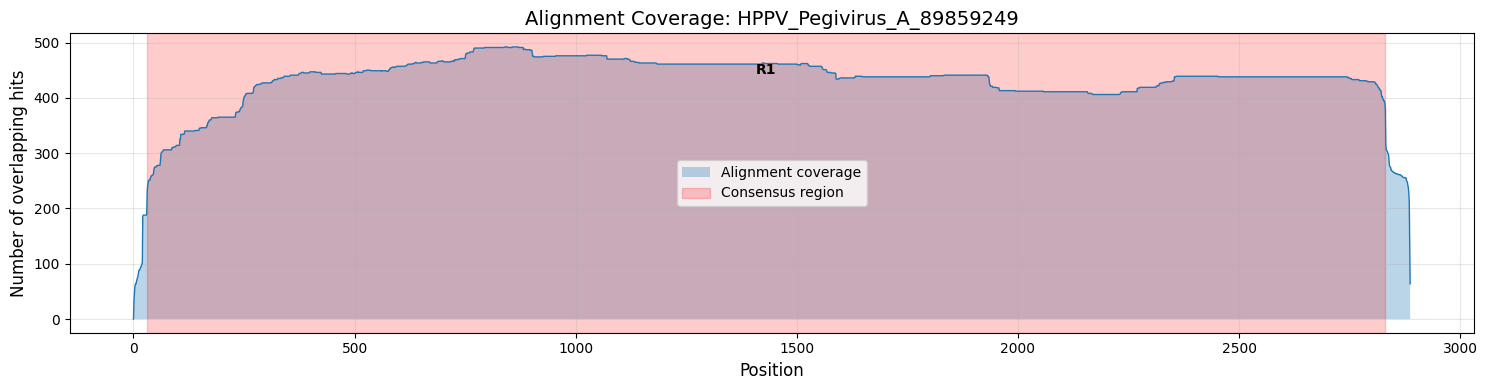

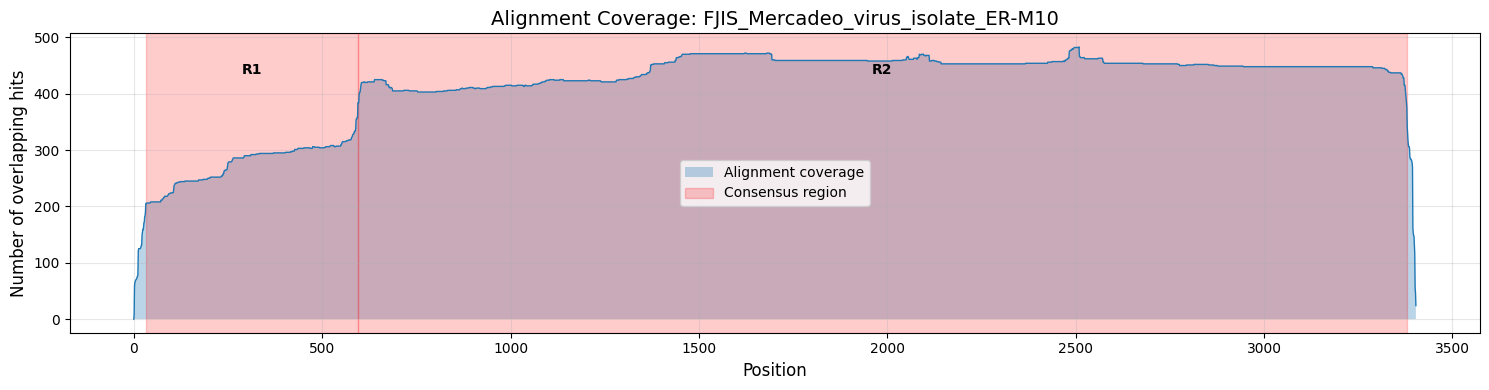

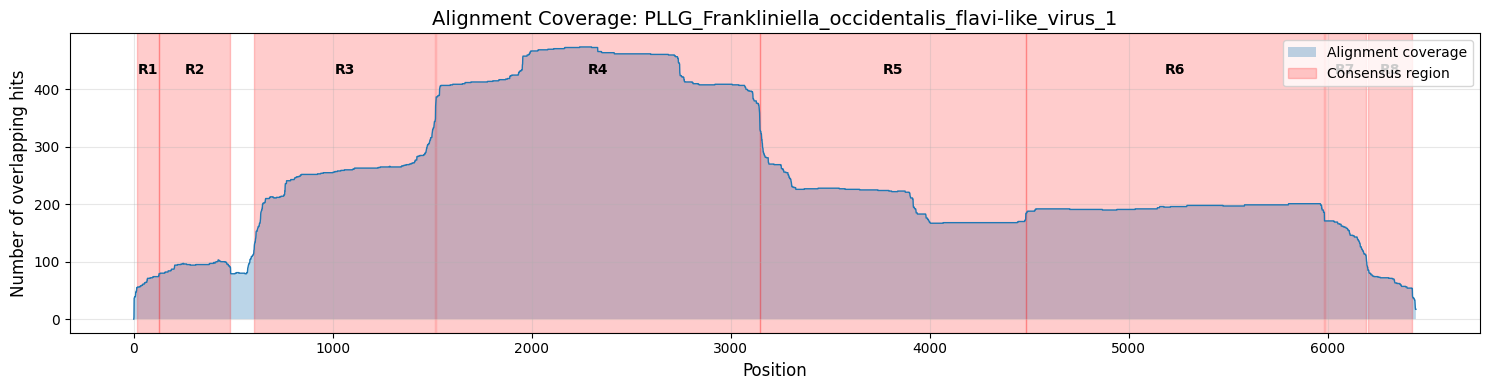

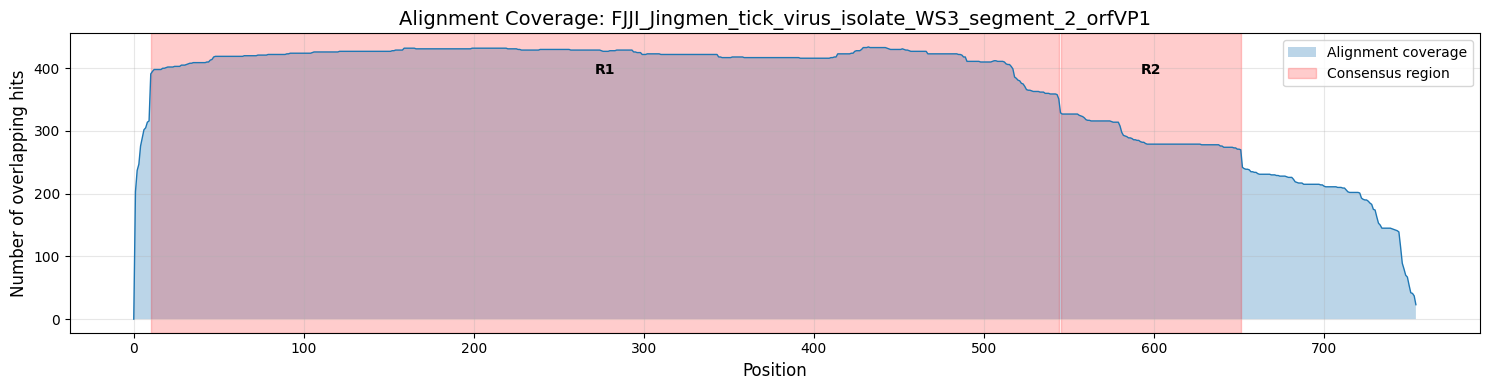

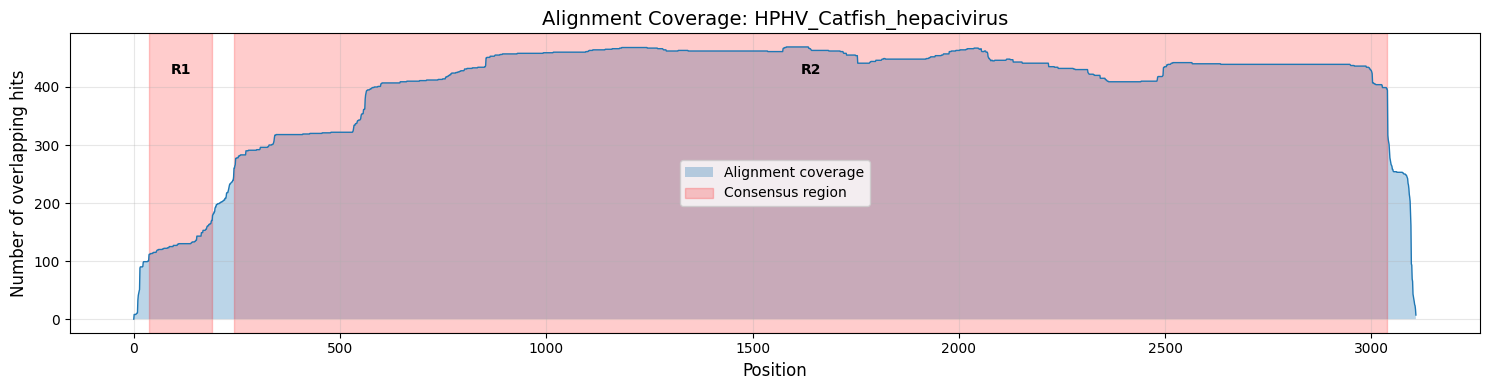

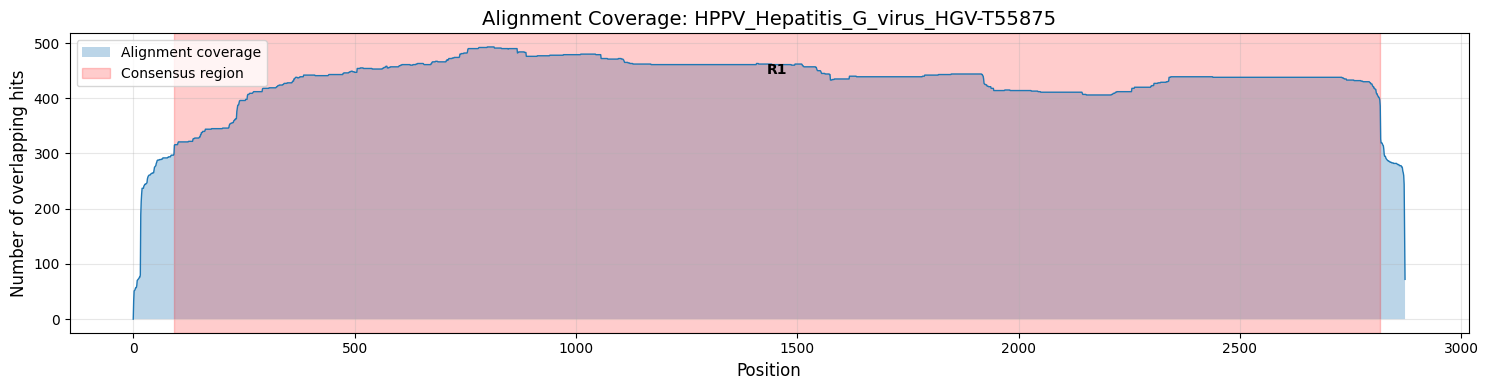

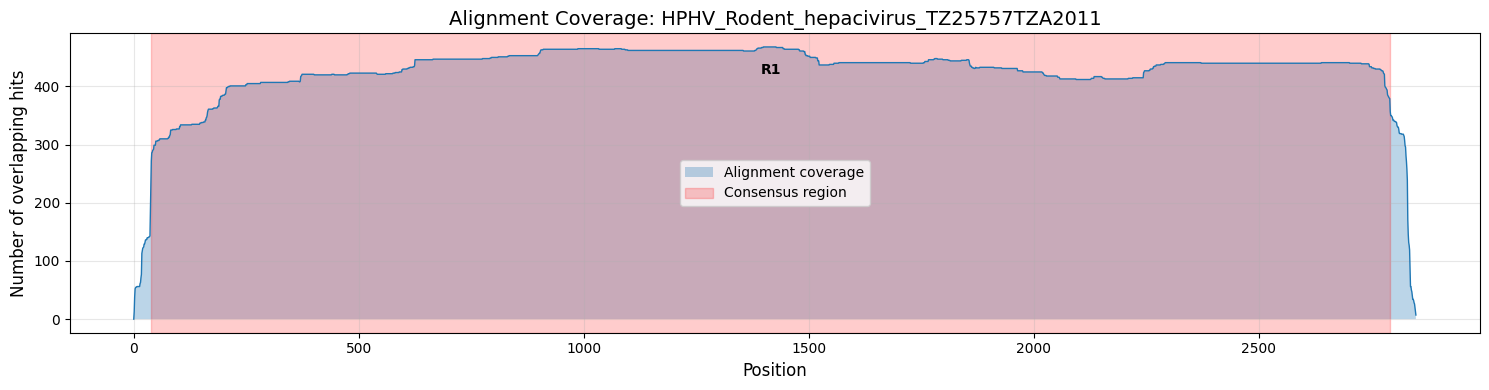

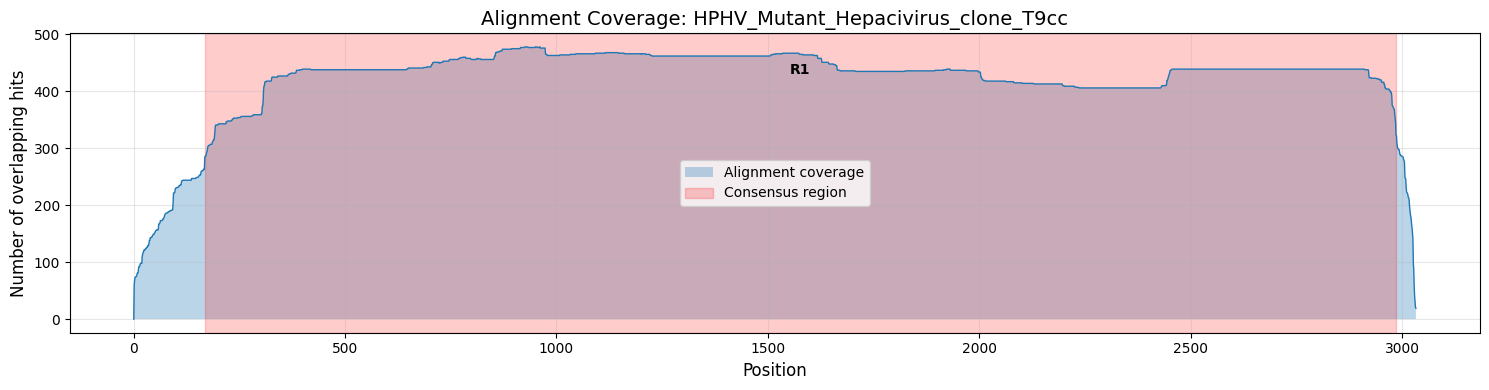

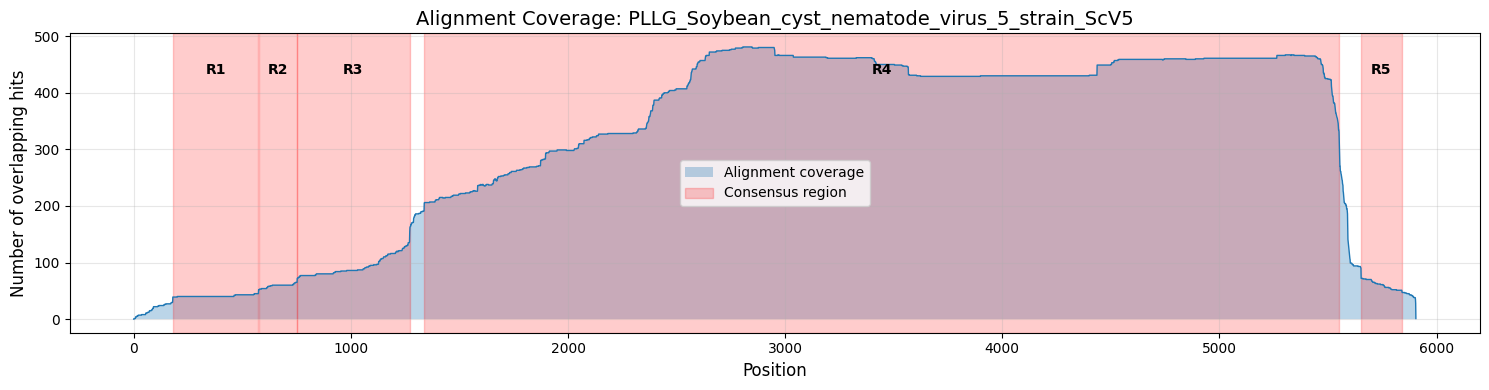

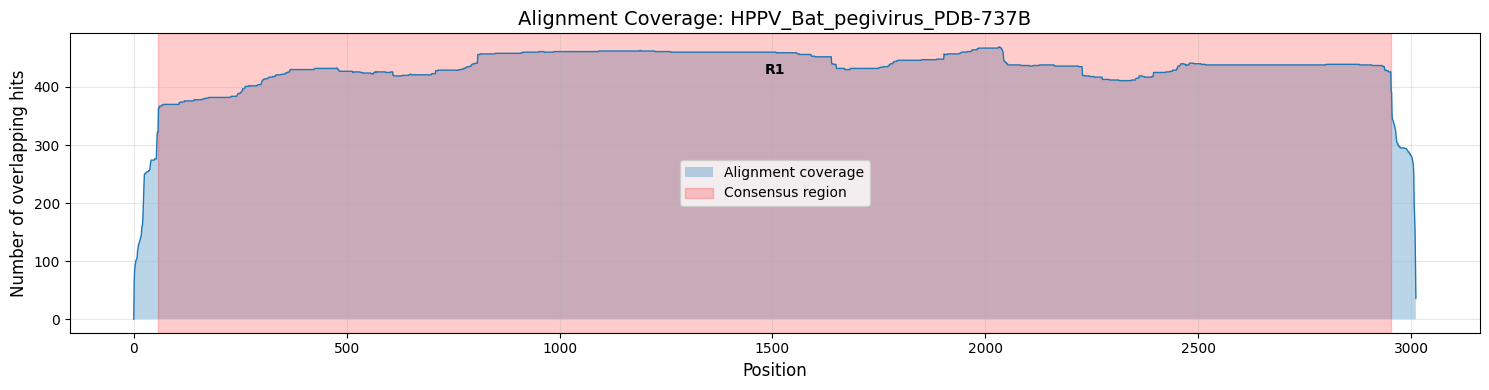

In [13]:
def plot_sequence_coverage(query_seq, alignments_df, consensus_regions, max_pos=None):
	"""
	Plot alignment coverage for a specific sequence with consensus regions highlighted.
	Works with Polars DataFrame.
	"""
	query_alns = alignments_df.filter(pl.col('query') == query_seq)
	
	if len(query_alns) == 0:
		print(f"No alignments found for {query_seq}")
		return
	
	# Determine sequence length
	if max_pos is None:
		max_pos = query_alns.select(pl.col('qend').max()).item()
	
	# Calculate coverage at each position using numpy for speed
	coverage = np.zeros(max_pos + 1)
	for row in query_alns.select(['qstart', 'qend']).to_dicts():
		coverage[row['qstart']:row['qend']+1] += 1
	
	# Plot
	fig, ax = plt.subplots(figsize=(15, 4))
	
	# Plot coverage
	positions = np.arange(len(coverage))
	ax.fill_between(positions, coverage, alpha=0.3, label='Alignment coverage')
	ax.plot(positions, coverage, linewidth=1)
	
	# Highlight consensus regions
	regions = consensus_regions.get(query_seq, [])
	for i, region in enumerate(regions):
		ax.axvspan(region['start'], region['end'], alpha=0.2, color='red', 
				   label='Consensus region' if i == 0 else '')
		ax.text((region['start'] + region['end']) / 2, coverage.max() * 0.9,
				f"R{i+1}", ha='center', fontsize=10, weight='bold')
	
	ax.set_xlabel('Position', fontsize=12)
	ax.set_ylabel('Number of overlapping hits', fontsize=12)
	ax.set_title(f'Alignment Coverage: {query_seq}', fontsize=14)
	ax.legend()
	ax.grid(alpha=0.3)
	
	plt.tight_layout()
	plt.show()
	
	return fig
#select 3 random keys

import random

for i in range( 10 ):
# Plot coverage for first sequence with regions
	first_seq = random.choice(list(consensus_regions.keys()))
	plot_sequence_coverage(first_seq, foldseek_results, consensus_regions)

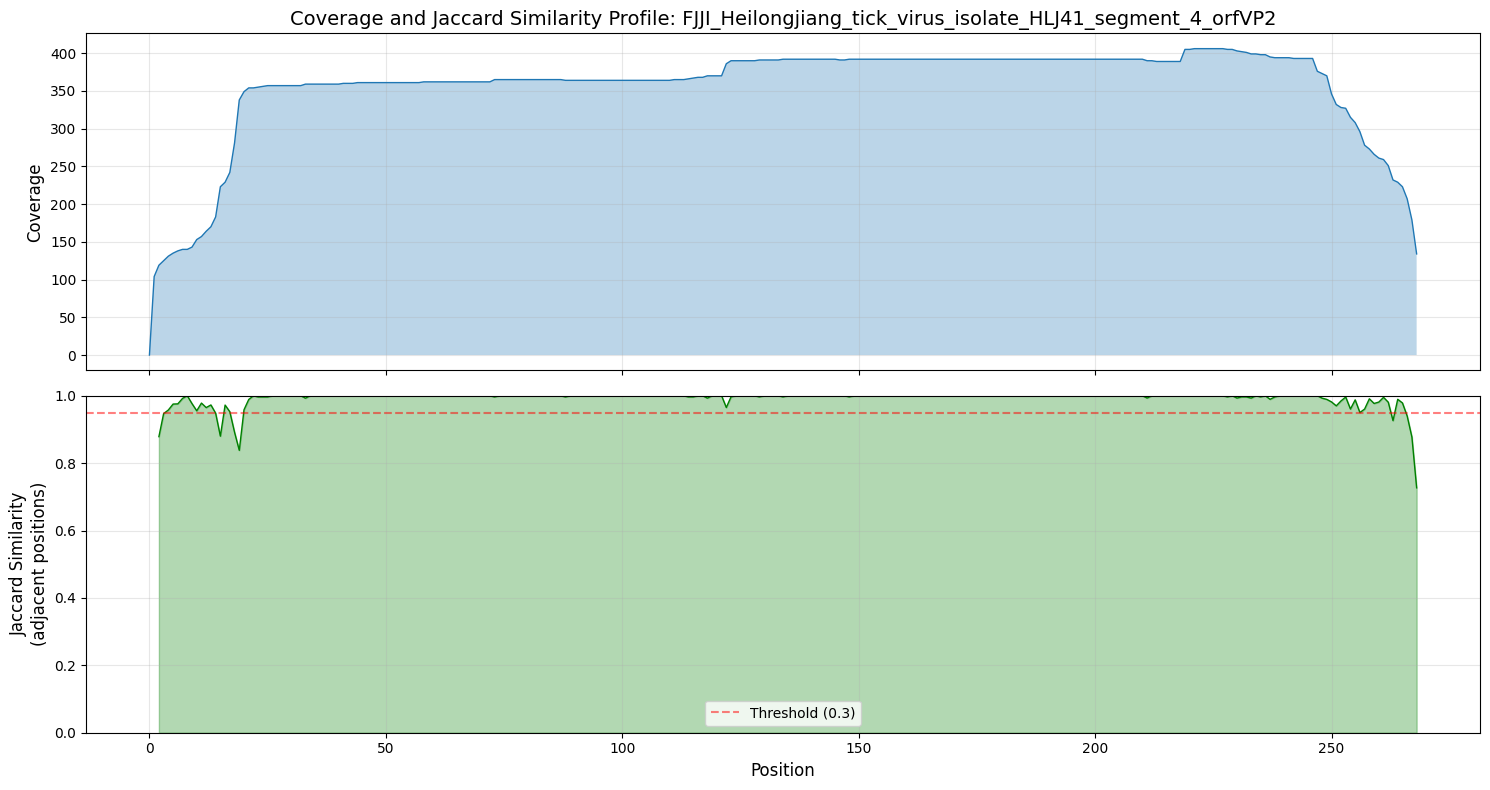

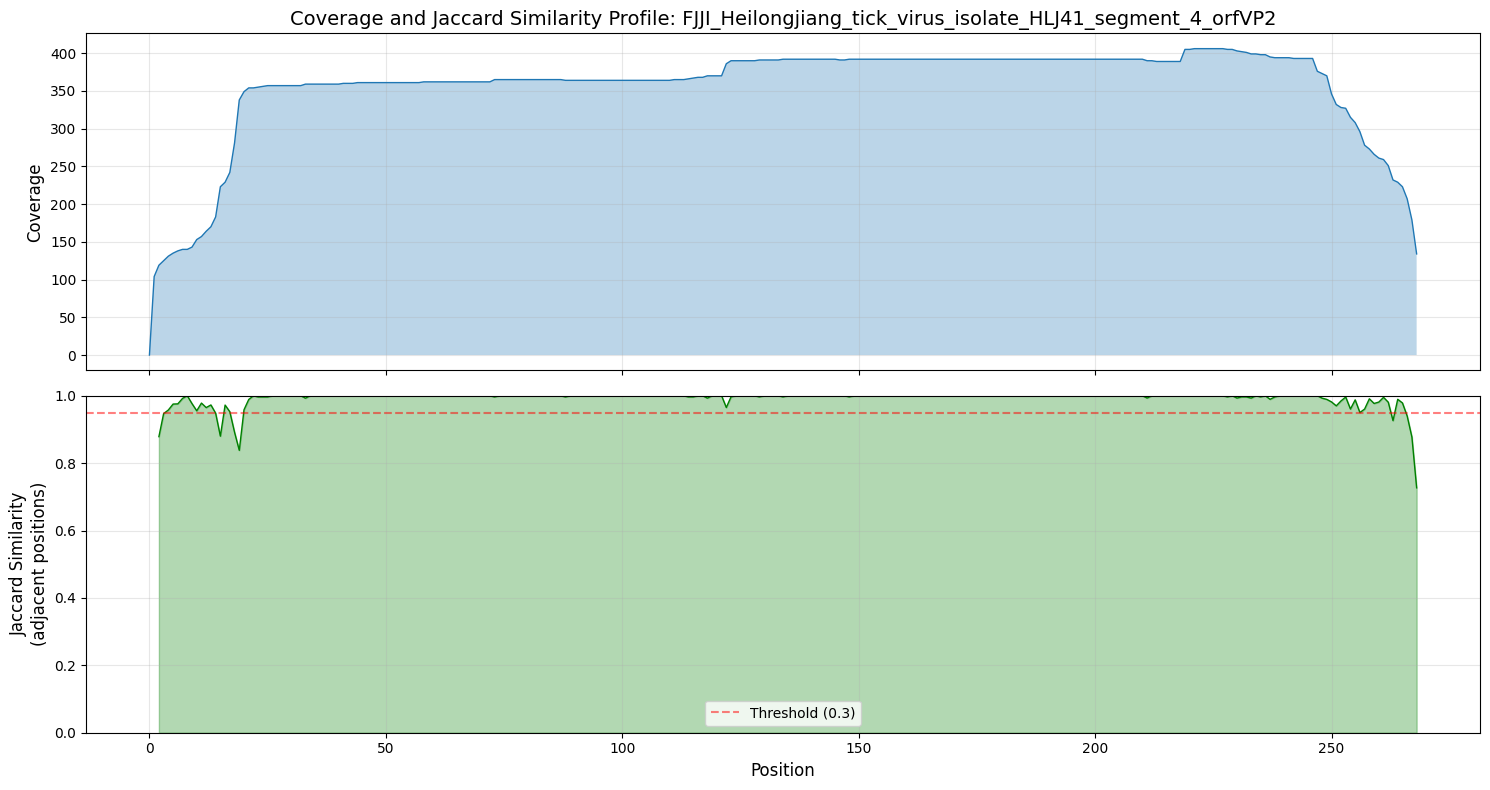

In [15]:
def plot_jaccard_profile(query_seq, alignments_df, metadata, max_pos=None):
	"""
	Plot Jaccard similarity profile showing how species composition changes along a sequence.
	"""
	query_alns = alignments_df.filter(pl.col('query') == query_seq)
	
	if len(query_alns) == 0:
		print(f"No alignments found for {query_seq}")
		return
	
	# Determine sequence length
	if max_pos is None:
		max_pos = query_alns.select(pl.col('qend').max()).item()
	
	# Precompute species mapping
	species_map = {
		row['seq_id']: row['species'] 
		for row in metadata.select(['seq_id', 'species']).to_dicts()
	}
	
	# Build species sets for each position
	position_species = {}
	intervals = query_alns.select(['qstart', 'qend', 'target']).to_dicts()
	
	for interval in intervals:
		species = species_map.get(interval['target'], 'unknown')
		for pos in range(interval['qstart'], interval['qend'] + 1):
			if pos not in position_species:
				position_species[pos] = set()
			position_species[pos].add(species)
	
	# Calculate Jaccard similarities between adjacent positions
	positions = sorted(position_species.keys())
	jaccard_scores = []
	jaccard_positions = []
	
	for i in range(1, len(positions)):
		prev_pos = positions[i-1]
		curr_pos = positions[i]
		
		if curr_pos - prev_pos <= 5:  # Only calculate for nearby positions
			prev_species = position_species[prev_pos]
			curr_species = position_species[curr_pos]
			
			intersection = len(prev_species & curr_species)
			union = len(prev_species | curr_species)
			jaccard = intersection / union if union > 0 else 0.0
			
			jaccard_scores.append(jaccard)
			jaccard_positions.append(curr_pos)
	
	# Plot
	fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
	
	# Plot 1: Coverage
	coverage = np.zeros(max_pos + 1)
	for row in query_alns.select(['qstart', 'qend']).to_dicts():
		coverage[row['qstart']:row['qend']+1] += 1
	
	ax1.fill_between(np.arange(len(coverage)), coverage, alpha=0.3)
	ax1.plot(coverage, linewidth=1)
	ax1.set_ylabel('Coverage', fontsize=12)
	ax1.grid(alpha=0.3)
	ax1.set_title(f'Coverage and Jaccard Similarity Profile: {query_seq}', fontsize=14)
	
	# Plot 2: Jaccard similarity
	ax2.plot(jaccard_positions, jaccard_scores, linewidth=1, color='green')
	ax2.axhline(y=.95, color='red', linestyle='--', alpha=0.5, label='Threshold (0.3)')
	ax2.fill_between(jaccard_positions, jaccard_scores, alpha=0.3, color='green')
	ax2.set_xlabel('Position', fontsize=12)
	ax2.set_ylabel('Jaccard Similarity\n(adjacent positions)', fontsize=12)
	ax2.set_ylim([0, 1])
	ax2.grid(alpha=0.3)
	ax2.legend()
	
	plt.tight_layout()
	plt.show()
	
	return fig

# Plot Jaccard profile for first sequence
first_seq = list(consensus_regions.keys())[0]
plot_jaccard_profile(first_seq, foldseek_results, unique_seqs)

## Export Consensus Regions

Save the identified consensus regions to files for downstream analysis.

In [16]:
# Convert consensus regions to DataFrame
regions_list = []
for seq_id, regions in consensus_regions.items():
	for i, region in enumerate(regions, 1):
		regions_list.append({
			'sequence_id': seq_id,
			'region_number': i,
			'start': region['start'],
			'end': region['end'],
			'length': region['end'] - region['start'] + 1,
			'avg_coverage': region['avg_coverage'],
			'max_coverage': region['max_coverage'],
			'species_support': region['species_count']
		})

regions_df = pd.DataFrame(regions_list)

# Save to file
output_file = 'consensus_regions.tsv'
regions_df.to_csv(output_file, sep='\t', index=False)
print(f"Saved {len(regions_df)} consensus regions to {output_file}")

# Display summary statistics
print("\nSummary Statistics:")
print(f"Total sequences with regions: {regions_df['sequence_id'].nunique()}")
print(f"Total regions identified: {len(regions_df)}")
print(f"Average region length: {regions_df['length'].mean():.1f} ± {regions_df['length'].std():.1f}")
print(f"Average coverage per region: {regions_df['avg_coverage'].mean():.1f}")

regions_df.head(10)

Saved 1186 consensus regions to consensus_regions.tsv

Summary Statistics:
Total sequences with regions: 610
Total regions identified: 1186
Average region length: 1391.7 ± 1376.6
Average coverage per region: 287.9


,sequence_id,region_number,start,end,length,avg_coverage,max_coverage,species_support
0,FJJI_Heilongjiang_tick_virus_isolate_HLJ41_seg...,1,19,249,231,379.147186,406,411
1,FJIS_Culiseta_flavivirus_strain_502-13,1,42,598,557,292.843806,381,394
2,FJIS_Culiseta_flavivirus_strain_502-13,2,599,3379,2781,444.265013,478,560
3,FJJI_Jingmen_tick_virus_isolate_WS3_segment_2_...,1,10,544,535,419.844860,434,464
4,FJJI_Jingmen_tick_virus_isolate_WS3_segment_2_...,2,545,651,107,293.121495,329,329
5,HPHV_Chaetodon_aureofaciatus_hepacivirus_isola...,1,69,231,163,262.128834,320,320
6,HPHV_Chaetodon_aureofaciatus_hepacivirus_isola...,2,232,2707,2476,445.074313,495,564
7,PLLG_Bole_tick_virus_4_isolate_TIGMIC_1,1,65,240,176,84.988636,90,90
8,PLLG_Bole_tick_virus_4_isolate_TIGMIC_1,2,307,434,128,141.320312,193,193
9,PLLG_Bole_tick_virus_4_isolate_TIGMIC_1,3,463,582,120,291.533333,324,324


## Generate BED-style Output for Polyprotein Domain Boundaries

Create a format suitable for extracting domain sequences from polyproteins.

In [17]:
# Create BED-style format for domain extraction
bed_output = []
for _, row in regions_df.iterrows():
	bed_output.append({
		'sequence_id': row['sequence_id'],
		'start': row['start'],
		'end': row['end'],
		'region_name': f"{row['sequence_id']}_domain_{row['region_number']}",
		'coverage': row['avg_coverage'],
		'strand': '+'
	})

bed_df = pd.DataFrame(bed_output)

# Save BED file
bed_file = 'polyprotein_domains.bed'
bed_df.to_csv(bed_file, sep='\t', index=False, header=False)
print(f"Saved domain boundaries to {bed_file}")

# Also create a more detailed annotation file
annotation_file = 'domain_annotations.tsv'
annotation_df = regions_df.copy()
annotation_df['domain_name'] = annotation_df.apply(
	lambda x: f"{x['sequence_id']}_domain_{x['region_number']}", axis=1
)
annotation_df.to_csv(annotation_file, sep='\t', index=False)
print(f"Saved domain annotations to {annotation_file}")

print("\nExample domain boundaries:")
bed_df.head(10)

Saved domain boundaries to polyprotein_domains.bed
Saved domain annotations to domain_annotations.tsv

Example domain boundaries:


,sequence_id,start,end,region_name,coverage,strand
0,FJJI_Heilongjiang_tick_virus_isolate_HLJ41_seg...,19,249,FJJI_Heilongjiang_tick_virus_isolate_HLJ41_seg...,379.147186,+
1,FJIS_Culiseta_flavivirus_strain_502-13,42,598,FJIS_Culiseta_flavivirus_strain_502-13_domain_1,292.843806,+
2,FJIS_Culiseta_flavivirus_strain_502-13,599,3379,FJIS_Culiseta_flavivirus_strain_502-13_domain_2,444.265013,+
3,FJJI_Jingmen_tick_virus_isolate_WS3_segment_2_...,10,544,FJJI_Jingmen_tick_virus_isolate_WS3_segment_2_...,419.844860,+
4,FJJI_Jingmen_tick_virus_isolate_WS3_segment_2_...,545,651,FJJI_Jingmen_tick_virus_isolate_WS3_segment_2_...,293.121495,+
5,HPHV_Chaetodon_aureofaciatus_hepacivirus_isola...,69,231,HPHV_Chaetodon_aureofaciatus_hepacivirus_isola...,262.128834,+
6,HPHV_Chaetodon_aureofaciatus_hepacivirus_isola...,232,2707,HPHV_Chaetodon_aureofaciatus_hepacivirus_isola...,445.074313,+
7,PLLG_Bole_tick_virus_4_isolate_TIGMIC_1,65,240,PLLG_Bole_tick_virus_4_isolate_TIGMIC_1_domain_1,84.988636,+
8,PLLG_Bole_tick_virus_4_isolate_TIGMIC_1,307,434,PLLG_Bole_tick_virus_4_isolate_TIGMIC_1_domain_2,141.320312,+
9,PLLG_Bole_tick_virus_4_isolate_TIGMIC_1,463,582,PLLG_Bole_tick_virus_4_isolate_TIGMIC_1_domain_3,291.533333,+


## Analyze Region Conservation Across Species

Examine how consensus regions are conserved across different species.

In [18]:
# Analyze species diversity for each region
def analyze_species_conservation(query_seq, region, alignments_df, metadata):
	"""
	Analyze which species have hits overlapping a given region.
	Uses Polars for efficient filtering and joining.
	"""
	# Filter alignments for this query and overlapping the region
	overlapping = alignments_df.filter(
		(pl.col('query') == query_seq) &
		(pl.col('qstart') <= region['end']) & 
		(pl.col('qend') >= region['start'])
	)
	
	# Join with metadata and count species
	species_counts = (
		overlapping
		.join(metadata, left_on='target', right_on='seq_id', how='left')
		.filter(pl.col('species').is_not_null())
		.group_by('species')
		.agg(pl.len().alias('count'))
		.sort('count', descending=True)
	)
	
	return {row['species']: row['count'] for row in species_counts.to_dicts()}

# Analyze first sequence with multiple regions
if consensus_regions:
	test_seq = list(consensus_regions.keys())[0]
	test_regions = consensus_regions[test_seq]
	
	if test_regions:
		print(f"Species conservation analysis for {test_seq}:\n")
		for i, region in enumerate(test_regions[:3], 1):  # Show first 3 regions
			species = analyze_species_conservation(
				test_seq, region, foldseek_results, unique_seqs
			)
			print(f"Region {i} ({region['start']}-{region['end']}):")
			print(f"  Total species: {len(species)}")
			for sp, count in sorted(species.items(), key=lambda x: x[1], reverse=True)[:5]:
				print(f"    {sp}: {count} hits")
			print()

Species conservation analysis for FJJI_Heilongjiang_tick_virus_isolate_HLJ41_segment_4_orfVP2:

Region 1 (19-249):
  Total species: 291
    Jingmen tick: 26 hits
    Flaviviridae sp.: 16 hits
    Mogiana tick: 7 hits
    Hepatitis C: 6 hits
    Bole tick: 6 hits



## Optional: Extract Domain Sequences

If you have the original sequences, you can extract the domain sequences based on the identified regions.

In [19]:
from Bio import SeqIO

def extract_domain_sequences(fasta_file, regions_df, output_file='extracted_domains.fasta'):
	"""
	Extract domain sequences from a FASTA file based on identified regions.
	
	Parameters:
	- fasta_file: Path to FASTA file with full-length sequences
	- regions_df: DataFrame with columns: sequence_id, start, end, region_number
	- output_file: Output FASTA file for extracted domains
	"""
	# Load sequences
	sequences = {rec.id: rec.seq for rec in SeqIO.parse(fasta_file, 'fasta')}
	
	# Extract domains
	extracted = []
	for _, row in regions_df.iterrows():
		seq_id = row['sequence_id']
		if seq_id in sequences:
			# Extract domain (1-based to 0-based indexing)
			domain_seq = sequences[seq_id][row['start']-1:row['end']]
			domain_id = f"{seq_id}_domain_{row['region_number']}"
			domain_desc = f"region {row['start']}-{row['end']} | length={len(domain_seq)}"
			
			from Bio.SeqRecord import SeqRecord
			record = SeqRecord(
				domain_seq,
				id=domain_id,
				description=domain_desc
			)
			extracted.append(record)
	
	# Write output
	SeqIO.write(extracted, output_file, 'fasta')
	print(f"Extracted {len(extracted)} domain sequences to {output_file}")
	
	return {'extracted_sequences': extracted , 'output_file': output_file}

# Example usage (uncomment and modify paths as needed):
fasta_file = 'flaviviridae_foldseek_db_aa.fasta'
extracted = extract_domain_sequences(fasta_file, regions_df)
fasta_file_3di = 'flaviviridae_foldseek_db_3di.fasta'
extracted3di = extract_domain_sequences(fasta_file_3di, regions_df, output_file='extracted_domains_3di.fasta')
print("Domain extraction function defined. Set fasta_file path and run to extract sequences.")

Extracted 1186 domain sequences to extracted_domains.fasta
Extracted 1186 domain sequences to extracted_domains_3di.fasta
Domain extraction function defined. Set fasta_file path and run to extract sequences.


In [20]:
# Create FoldSeek database from extracted domain sequences
db_path = 'flaviviridae_foldseek_domains_db'
fasta_to_foldseek_db(
	input_fasta=extracted['output_file'],
	output_db=Path(db_path),
	model_ckpt=Path("../checkpoints_ESMplusplus_small/epoch_3.pt"),
	device="cuda:0",
	keep_fastas=True
)
print(f"Created FoldSeek database at {db_path}")

Running FoldSeek database creation:
  Input: extracted_domains.fasta
  Output: flaviviridae_foldseek_domains_db
  Model: ../checkpoints_ESMplusplus_small/epoch_3.pt
  Command: python ../fastas2foldseekdb.py --aa-fasta extracted_domains.fasta --model-ckpt ../checkpoints_ESMplusplus_small/epoch_3.pt --output-db flaviviridae_foldseek_domains_db --device cuda:0 --keep-fastas
✓ Successfully created FoldSeek database at flaviviridae_foldseek_domains_db
Created FoldSeek database at flaviviridae_foldseek_domains_db


In [21]:
#run foldseek all-vs-all with 3di database
foldseek_allvall(
	input_fasta=Path(db_path),
	output_path='domains_allvall.tsv',
)

Running Foldseek command: foldseek easy-search flaviviridae_foldseek_domains_db flaviviridae_foldseek_domains_db domains_allvall.tsv tmp --format-output query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln
domains_allvall.tsv exists and will be overwritten
easy-search flaviviridae_foldseek_domains_db flaviviridae_foldseek_domains_db domains_allvall.tsv tmp --format-output query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln 

MMseqs Version:                    	10.941cd33
Seq. id. threshold                 	0
Coverage threshold                 	0
Coverage mode                      	0
Max reject                         	2147483647
Max accept                         	2147483647
Add backtrace                      	false
TMscore threshold                  	0
TMscore threshold mode             	0
TMalign hit order                  	0
TMalign fast                       	1
Preload mode                       	0
Threads  

In [22]:
#read the all vs all domain foldseek results
domain_foldseek_results = pl.read_csv(
	'domains_allvall.tsv',
	#tab separated
	separator='\t',
	has_header=False
)
print(f"Loaded {len(domain_foldseek_results)} domain alignments")

#add column info query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln
domain_foldseek_results.columns = [
	'query', 'target', 'fident', 'alnlen', 'mismatch', 'gapopen',
	'qstart', 'qend', 'tstart', 'tend', 'evalue', 'bits', 'qaln', 'taln'
]
print(domain_foldseek_results.head())

Loaded 601202 domain alignments
shape: (5, 14)
┌──────────────┬──────────────┬────────┬────────┬───┬────────┬───────┬──────────────┬──────────────┐
│ query        ┆ target       ┆ fident ┆ alnlen ┆ … ┆ evalue ┆ bits  ┆ qaln         ┆ taln         │
│ ---          ┆ ---          ┆ ---    ┆ ---    ┆   ┆ ---    ┆ ---   ┆ ---          ┆ ---          │
│ str          ┆ str          ┆ f64    ┆ i64    ┆   ┆ f64    ┆ i64   ┆ str          ┆ str          │
╞══════════════╪══════════════╪════════╪════════╪═══╪════════╪═══════╪══════════════╪══════════════╡
│ PLPV_Classic ┆ PLPV_Classic ┆ 1.0    ┆ 3519   ┆ … ┆ 0.0    ┆ 25390 ┆ AEGPPAKECAVT ┆ AEGPPAKECAVT │
│ al_swine_fev ┆ al_swine_fev ┆        ┆        ┆   ┆        ┆       ┆ CRYDKDADINVV ┆ CRYDKDADINVV │
│ er_vir…      ┆ er_vir…      ┆        ┆        ┆   ┆        ┆       ┆ TQARNR…      ┆ TQARNR…      │
│ PLPV_Classic ┆ PLPV_Pestivi ┆ 0.853  ┆ 3466   ┆ … ┆ 0.0    ┆ 20295 ┆ AEGPPAKECAVT ┆ TEGPPDKECAVT │
│ al_swine_fev ┆ rus_sp._isol ┆        ┆    

In [23]:
#add sequence lengths to the dataframe
from Bio import SeqIO

# Load domain sequences and compute lengths
seqlens = {}
for rec in SeqIO.parse('extracted_domains.fasta', 'fasta'):
	seqlens[rec.id] = len(rec.seq)

print(f"Loaded sequence lengths for {len(seqlens)} domains")

# Add query and target lengths to domain_foldseek_results
domain_foldseek_results = domain_foldseek_results.with_columns([
	pl.col('query').map_elements(lambda x: seqlens.get(x, 0), return_dtype=pl.Int64).alias('qlen'),
	pl.col('target').map_elements(lambda x: seqlens.get(x, 0), return_dtype=pl.Int64).alias('tlen')
])

print("\nUpdated domain_foldseek_results with sequence lengths:")
print(domain_foldseek_results.select(['query', 'target', 'qlen', 'tlen', 'alnlen']).head())

Loaded sequence lengths for 1186 domains

Updated domain_foldseek_results with sequence lengths:
shape: (5, 5)
┌─────────────────────────────────┬─────────────────────────────────┬──────┬──────┬────────┐
│ query                           ┆ target                          ┆ qlen ┆ tlen ┆ alnlen │
│ ---                             ┆ ---                             ┆ ---  ┆ ---  ┆ ---    │
│ str                             ┆ str                             ┆ i64  ┆ i64  ┆ i64    │
╞═════════════════════════════════╪═════════════════════════════════╪══════╪══════╪════════╡
│ PLPV_Classical_swine_fever_vir… ┆ PLPV_Classical_swine_fever_vir… ┆ 3519 ┆ 3519 ┆ 3519   │
│ PLPV_Classical_swine_fever_vir… ┆ PLPV_Pestivirus_sp._isolate_ov… ┆ 3519 ┆ 3450 ┆ 3466   │
│ PLPV_Classical_swine_fever_vir… ┆ PLPV_Tunisian_small_ruminant_p… ┆ 3519 ┆ 3872 ┆ 3524   │
│ PLPV_Classical_swine_fever_vir… ┆ PLPV_Pestivirus_strain_Aydin04… ┆ 3519 ┆ 3519 ┆ 3539   │
│ PLPV_Classical_swine_fever_vir… ┆ PLPV_Pestivirus_

In [74]:
#cluster the domains into groups based on their alignments
import networkx as nx

def cluster_domains(alignments_df, identity_threshold=0.3, coverage_threshold=0.5):
	"""
	Cluster domains using a graph + Louvain community detection.

	An undirected edge is added between two domains when both conditions hold:
	- fident >= identity_threshold
	- coverage of the shorter domain >= coverage_threshold

	Edge weight is fident * coverage; communities are detected with Louvain.
	"""
	G = nx.Graph()

	for row in alignments_df.to_dicts():
		query = row['query']
		target = row['target']
		if query == target:
			continue  # skip self-edges

		fident = row['fident'] 
		alnlen = row['alnlen']

		# Use actual sequence lengths from qlen/tlen columns
		qlen = row.get('qlen', alnlen)
		tlen = row.get('tlen', alnlen)
		
		# Coverage of the shorter domain
		shorter_len = min(qlen, tlen)
		longer_len = max(qlen, tlen)
		covered_shorter = alnlen / shorter_len if shorter_len > 0 else 0
		covered_longer = alnlen / longer_len if longer_len > 0 else 0

		if fident < identity_threshold or covered_longer < coverage_threshold:
			continue

		weight = fident * covered_shorter
		G.add_edge(query, target, weight=weight, fident=fident, coverage=covered_shorter, alnlen=alnlen)

	if G.number_of_nodes() == 0:
		return []

	communities = nx.algorithms.community.louvain_communities(G, weight='weight', seed=42)
	return [set(comm) for comm in communities] , G

domain_clusters, domain_graph = cluster_domains(domain_foldseek_results, identity_threshold=0.2, coverage_threshold=0.50)


Identified 66 domain clusters:
Graph has 928 nodes and 26851 edges


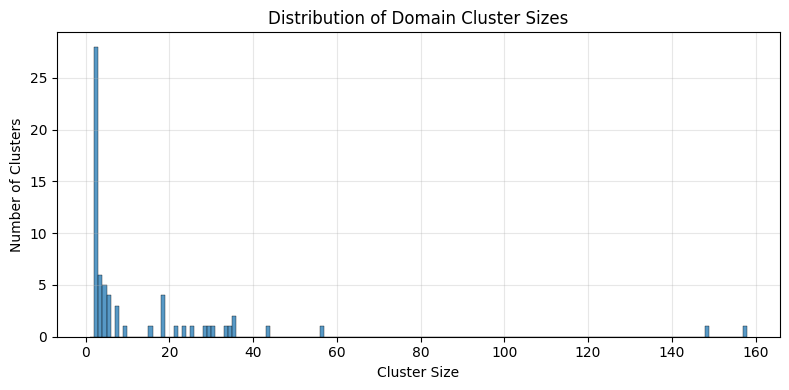

In [75]:
#print summary of clusters
print(f"\nIdentified {len(domain_clusters)} domain clusters:")

#print number of graph nodes and edges
print(f"Graph has {domain_graph.number_of_nodes()} nodes and {domain_graph.number_of_edges()} edges")

#show histogram of cluster sizes
cluster_sizes = [len(cluster) for cluster in domain_clusters]
plt.figure(figsize=(8, 4))
sns.histplot(cluster_sizes, bins=range(1, max(cluster_sizes)+2), kde=False)
plt.xlabel('Cluster Size')
plt.ylabel('Number of Clusters')
plt.title('Distribution of Domain Cluster Sizes')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

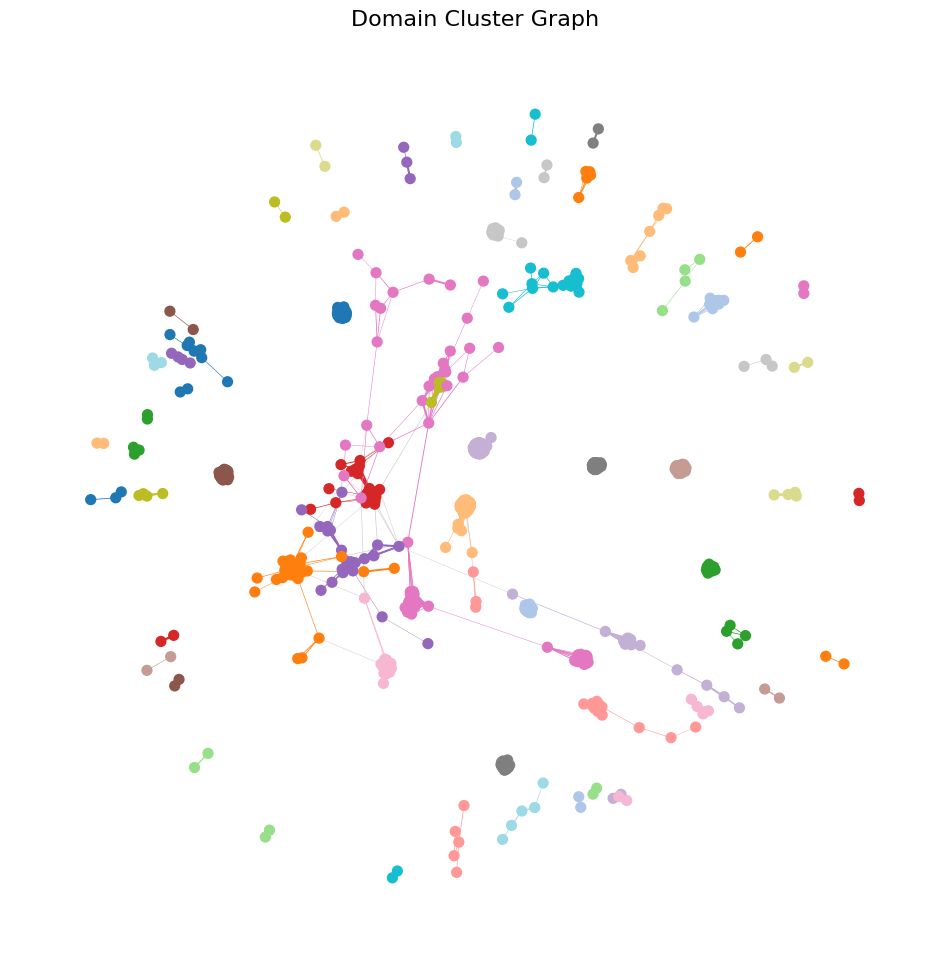

In [76]:
#show the domain cluster graph 
#use weight as edge thickness
#color nodes by cluster
#color edges by cluster color if both nodes are in same cluster else gray
import matplotlib.pyplot as plt

def plot_domain_cluster_graph(domain_graph, domain_clusters):
	plt.figure(figsize=(12, 12))
	pos = nx.spring_layout(domain_graph, seed=42)

	# Assign colors to clusters
	cluster_colors = {}
	for i, cluster in enumerate(domain_clusters):
		color = plt.cm.tab20(i % 20)  # Use tab20 colormap for up to 20 distinct colors
		for node in cluster:
			cluster_colors[node] = color

	# Draw nodes with cluster colors
	node_colors = [cluster_colors.get(node, (0.5, 0.5, 0.5)) for node in domain_graph.nodes()]
	nx.draw_networkx_nodes(domain_graph, pos, node_color=node_colors, node_size=50)

	# Draw edges with colors based on cluster membership
	edge_colors = []
	for u, v in domain_graph.edges():
		if cluster_colors.get(u) == cluster_colors.get(v):
			edge_colors.append(cluster_colors[u])
		else:
			edge_colors.append((0.8, 0.8, 0.8))  # Gray for inter-cluster edges

	edge_weights = [domain_graph[u][v]['weight'] for u, v in domain_graph.edges()]
	nx.draw_networkx_edges(domain_graph, pos, edge_color=edge_colors, width=[2 * w  for w in edge_weights])

	#nx.draw_networkx_labels(domain_graph, pos, font_size=8)

	plt.title('Domain Cluster Graph', fontsize=16)
	plt.axis('off')
	plt.show()
plot_domain_cluster_graph(domain_graph, domain_clusters)

In [77]:
#map clusters to the closest single chain pdb reference structure
ref_structures_folder = '/home/dmoi/projects/ESM3di/flavi_redo/Single_Chain_RSCB_PDB_References/'
domains_db = 'flaviviridae_foldseek_domains_db'
#foldseek the extracted domains against the reference structures
foldseek_allvdb(
	input_fasta=domains_db,
	db_path=Path(ref_structures_folder),
	output_path='domains_vs_refstructs.tsv',
)
#read the foldseek results
ref_foldseek_results = pl.read_csv(
	'domains_vs_refstructs.tsv',
	separator='\t',
	has_header=False
)
#add column info query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln
ref_foldseek_results.columns = [
	'query', 'target', 'fident', 'alnlen', 'mismatch', 'gapopen',
	'qstart', 'qend', 'tstart', 'tend', 'evalue', 'bits', 'qaln', 'taln'
]
print(f"Loaded {len(ref_foldseek_results)} reference structure alignments")


Running Foldseek command: foldseek easy-search flaviviridae_foldseek_domains_db /home/dmoi/projects/ESM3di/flavi_redo/Single_Chain_RSCB_PDB_References domains_vs_refstructs.tsv tmp --format-output query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln
domains_vs_refstructs.tsv exists and will be overwritten
easy-search flaviviridae_foldseek_domains_db /home/dmoi/projects/ESM3di/flavi_redo/Single_Chain_RSCB_PDB_References domains_vs_refstructs.tsv tmp --format-output query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln 

MMseqs Version:                    	10.941cd33
Seq. id. threshold                 	0
Coverage threshold                 	0
Coverage mode                      	0
Max reject                         	2147483647
Max accept                         	2147483647
Add backtrace                      	false
TMscore threshold                  	0
TMscore threshold mode             	0
TMalign hit order            

In [116]:
domain_clusters_map = {domain: i for i, cluster in enumerate(domain_clusters) for domain in cluster}
#map clusters to domains in the ref_foldseek_results
ref_foldseek_results = ref_foldseek_results.with_columns([
	pl.col('query').map_elements(lambda x: domain_clusters_map.get(x, -1), return_dtype=pl.Int64).alias('cluster_id')
])	
#show the top reference structures for each cluster
for cluster_id in range(len(domain_clusters)):
	cluster_hits = ref_foldseek_results.filter(pl.col('cluster_id') == cluster_id)
	if len(cluster_hits) == 0:
		continue
	#select first row with highest bitscore
	top_hit = cluster_hits.sort('bits', descending=True).row(0)
	top_hit = dict( zip(cluster_hits.columns, top_hit) )
	print(f"Cluster {cluster_id}: Top reference structure hit:")
	print(f"  Query domain: {top_hit['query']}")
	print(f"  Target structure: {top_hit['target']}")
	print(f"  Identity: {top_hit['fident']:.2f}%")
	print(f"  Alignment length: {top_hit['alnlen']}")
	print(f"  E-value: {top_hit['evalue']:.2e}")
	print(f"  Bitscore: {top_hit['bits']}")
	print(f"alingnment:\n{top_hit['qaln']}\n{top_hit['taln']}")
	print()

Cluster 0: Top reference structure hit:
  Query domain: PLPV_Bovine_viral_diarrhea_virus_1_domain_1
  Target structure: PLPV_E2_2YQ2_A
  Identity: 0.86%
  Alignment length: 330
  E-value: 5.35e-19
  Bitscore: 904
alingnment:
CKPEFSYAIAKDERIGQLGAEGLTTTWKEYSPGMKLEDTMVIAWCEDGKLMYLQRCTRETRYLAILHTRALPTSVVFKKLFDGRKQEDVVEMNDNFEFGLCPCDAKPIVRGKFNTTLLNGPAFQMVCPIGWTGTVSCTSFNMDTLATTVVRTYRRSKPFPHRQGCITQKNLGEDLHNCILGGNWTCVPGDQLLYKGGSIESCKWCGYQFKESEGLPHYPIGKCKLENETGYRLVDSTSCNREGVAIVPQGTLKCKIGKTTVQVIAMDTKLGPMPCRPYEIISSEGPVEKTACTFNYTKTLKNKYFEPRDSYFQQYMLKGEYQYWFDLEVT
CKPEYYYAIAKNDRIGPLGAEGLTTVWKDYSPEMTLEDTMVIASCRDGKFMYLSRCTRETRYLAILHSRALPTSVVFKKLFEGQKQGDTVEMDDDFEFGLCPCDAKPIVRGKYNTTLLNGPAFQMVCPIGWTGTVSCMLANRDTLDTAVVRTYRRSRPFPYRQGCITQKVLGEDLYDCILGGNWTCVTGDQLQYSGGSIESCKWCGFKFQRSEGLPHYPIGKCRLKNETGYRLVDNTSCNREGVAIVPQGTVKCKIGDTTVQVIALDTKLGPMPCKPYEIISSEGPVEKTACTFNYTKTLKNKYFEPRDSYFQQYMLKGEYQYWFDLEVT

Cluster 1: Top reference structure hit:
  Query domain: PLLG_Camel_tick_virus_isolate_Alain_domain_4
  Target st

In [118]:
pip install py3dmol

Note: you may need to restart the kernel to use updated packages.


In [119]:
#show FJMB_NS5_RdRp_5F3Z with py3dmol
import py3dmol
def show_structure_pdb(pdb_id, selection="all", style="cartoon", color="spectrum"):
	"""
	Display a PDB structure using py3dmol.
	
	Parameters:
	- pdb_id: PDB ID of the structure to display
	- selection: Atom selection string (default: "all")
	- style: Visualization style (default: "cartoon")
	- color: Color scheme (default: "spectrum")
	"""
	view = py3dmol.view(query=f'pdb:{pdb_id}')
	view.setStyle({selection: {style: { 'color': color }}})
	view.zoomTo()
	return view.show()
show_structure_pdb('5F3Z', style='cartoon', color='spectrum')

ModuleNotFoundError: No module named 'py3dmol'

In [79]:
print(f"Identified {len(domain_clusters)} domain clusters")
for i, cluster in enumerate(domain_clusters[:5], 1):  # Show first 5 clusters
	print(f"Cluster {i} ({len(cluster)} domains): {list(cluster)[:5]}{'...' if len(cluster) > 5 else ''}")

Identified 66 domain clusters
Cluster 1 (34 domains): ['PLPV_Bovine_viral_diarrhea_virus_3_Th04_KhonKaen_domain_2', 'PLPV_Pangolin_pestivirus_strain_PPeVBIME1P019Tpangolin2018_domain_1', 'PLPV_Bat_pestivirus_BtSk-PestV-1GX2017_domain_1', 'PLPV_Pangolin_pestivirus_1_isolate_ZJ-F1_domain_1', 'PLPV_Rodent_pestivirus_isolate_RtAp-PestVJL2014_domain_2']...
Cluster 2 (30 domains): ['PLLG_Bole_tick_virus_4_strain_IftinH.dromedarii2018_domain_4', 'PLLG_Haseki_tick_virus_strain_Novosibirsk-2020_domain_3', 'PLLG_Bole_tick_virus_4_strain_NE-ShL2_domain_4', 'PLLG_Flaviviridae_sp._isolate_TIGMIC_1_domain_3', 'PLLG_Flaviviridae_sp._isolate_TIGMIC_28_domain_3']...
Cluster 3 (35 domains): ['HPHV_Hepacivirus_horseDH1HUN2013_domain_1', 'HPHV_Rodent_hepacivirus_MOZ329-CMOZ2011_domain_1', 'HPHV_Recombinant_Hepacivirus_domain_1', 'HPHV_Hepacivirus_M_domain_1', 'HPHV_Gerbil_hepacivirus_domain_1']...
Cluster 4 (148 domains): ['FJMB_Sepik_virus_domain_2', 'FJMB_Sokoluk_virus_strain_LEIV-400K_domain_2', 'FJMB_

32 clusters have at least 4 domains


(array([48., 10.,  5.,  1.,  0.,  0.,  0.,  0.,  0.,  2.]),
 array([  2. ,  17.5,  33. ,  48.5,  64. ,  79.5,  95. , 110.5, 126. ,
        141.5, 157. ]),
 <BarContainer object of 10 artists>)

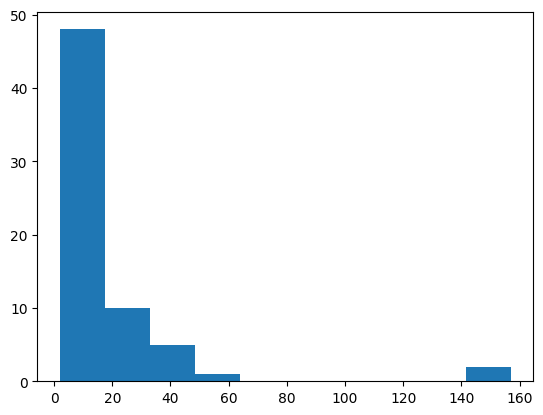

In [80]:
#filter clusters to only those with at least 5 domains
filtered_clusters = [cluster for cluster in domain_clusters if len(cluster) >= 4]
print(f"{len(filtered_clusters)} clusters have at least 4 domains")
#show histogram of number of sequences per domain
from matplotlib import pyplot as plt

plt.hist( [len(c) for c in domain_clusters] )


In [81]:
#create a fasta for each cluster
import os

def clusters2fastas(clusters,fasta_file, fasta_file_3di , output_dir='domain_clusters_fasta'):
	"""
	Create a FASTA file for each cluster of domains.
	
	Parameters:
	- clusters: List of clusters, each cluster is a set of domain IDs
	- fasta_file: Path to FASTA file with full-length domain sequences
	- fasta_file_3di: Path to FASTA file with 3di domain sequences
	- output_dir: Directory to save cluster FASTA files
	"""
	from Bio import SeqIO
	from Bio.SeqRecord import SeqRecord
	import os
	
	# Load sequences
	sequences = {rec.id: rec.seq for rec in SeqIO.parse(fasta_file, 'fasta')}
	sequences_3di = {rec.id: rec.seq for rec in SeqIO.parse(fasta_file_3di, 'fasta')}
	print(f"Loaded {len(sequences)} sequences from {fasta_file}")
	print(f"Loaded {len(sequences_3di)} sequences from {fasta_file_3di}")
	# Create output directory
	for i, cluster in enumerate(clusters, 1):
		cluster_seqs = []
		cluster_seqs_3di = []
		for domain_id in cluster:
			if domain_id in sequences:
				record = SeqRecord(
					sequences[domain_id],
					id=domain_id,
					description=f"Cluster {i}"
				)
				cluster_seqs.append(record)
				cluster_seqs_3di.append(
					SeqRecord(
						sequences_3di[domain_id],
						id=domain_id,
						description=f"Cluster {i}"
					)
				)
		print(f"Cluster {i} has {len(cluster_seqs)} sequences")
		# Write cluster FASTA
		os.makedirs(output_dir, exist_ok=True)
		#make a folder for each cluster
		os.makedirs(os.path.join(output_dir, f'cluster_{i}'), exist_ok=True)
		
		cluster_fasta_file = os.path.join(os.path.join(output_dir, f'cluster_{i}'), f'cluster_{i}.fasta')
		cluster_fasta_file_3di = os.path.join(os.path.join(output_dir, f'cluster_{i}'), f'cluster_{i}_3di.fasta')
		SeqIO.write(cluster_seqs_3di, cluster_fasta_file_3di, 'fasta')
		SeqIO.write(cluster_seqs, cluster_fasta_file, 'fasta')
		
		print(f"Saved cluster {i} with {len(cluster_seqs)} sequences to {cluster_fasta_file}")

#clear the outputdir folder if anything is in there
import shutil	
output_dir = 'domain_clusters_fasta'
shutil.rmtree( output_dir)
os.makedirs(output_dir, exist_ok=True)
os.makedirs('domain_clusters_fasta', exist_ok=True)
clusters2fastas(filtered_clusters, fasta_file='extracted_domains.fasta', fasta_file_3di='extracted_domains_3di.fasta', output_dir='domain_clusters_fasta')

Loaded 1186 sequences from extracted_domains.fasta
Loaded 1186 sequences from extracted_domains_3di.fasta
Cluster 1 has 34 sequences
Saved cluster 1 with 34 sequences to domain_clusters_fasta/cluster_1/cluster_1.fasta
Cluster 2 has 30 sequences
Saved cluster 2 with 30 sequences to domain_clusters_fasta/cluster_2/cluster_2.fasta
Cluster 3 has 35 sequences
Saved cluster 3 with 35 sequences to domain_clusters_fasta/cluster_3/cluster_3.fasta
Cluster 4 has 148 sequences
Saved cluster 4 with 148 sequences to domain_clusters_fasta/cluster_4/cluster_4.fasta
Cluster 5 has 18 sequences
Saved cluster 5 with 18 sequences to domain_clusters_fasta/cluster_5/cluster_5.fasta
Cluster 6 has 4 sequences
Saved cluster 6 with 4 sequences to domain_clusters_fasta/cluster_6/cluster_6.fasta
Cluster 7 has 43 sequences
Saved cluster 7 with 43 sequences to domain_clusters_fasta/cluster_7/cluster_7.fasta
Cluster 8 has 23 sequences
Saved cluster 8 with 23 sequences to domain_clusters_fasta/cluster_8/cluster_8.fast

In [82]:
#assign a color to each cluster for visualization
def assign_cluster_colors(clusters):
	"""
	Assign a unique color to each cluster.
	
	Parameters:
	- clusters: List of clusters, each cluster is a set of domain IDs
	
	Returns:
	- Dictionary mapping domain IDs to colors
	"""
	import matplotlib.pyplot as plt
	import numpy as np
	
	num_clusters = len(clusters)
	cmap = plt.get_cmap('tab20')
	colors = [cmap(i % 20) for i in range(num_clusters)]
	
	domain_colors = {}
	for i, cluster in enumerate(clusters):
		color = colors[i]
		for domain_id in cluster:
			domain_colors[domain_id] = color
	
	return domain_colors
domain_colors = assign_cluster_colors(domain_clusters)
print(f"Assigned colors to {len(domain_colors)} domains across {len(domain_clusters)} clusters")

Assigned colors to 928 domains across 66 clusters


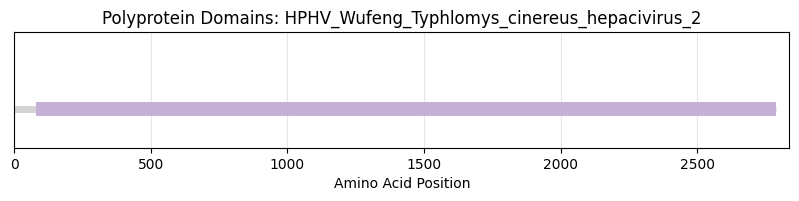

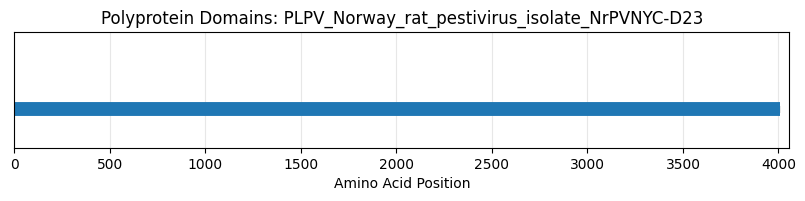

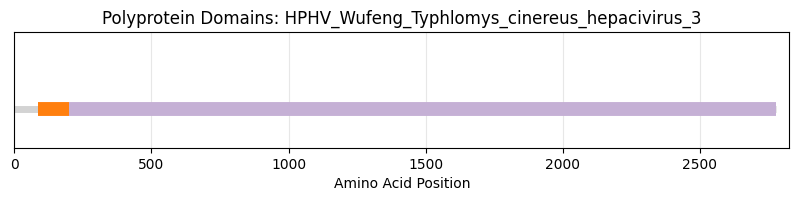

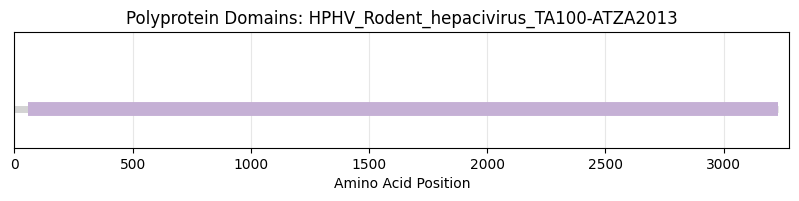

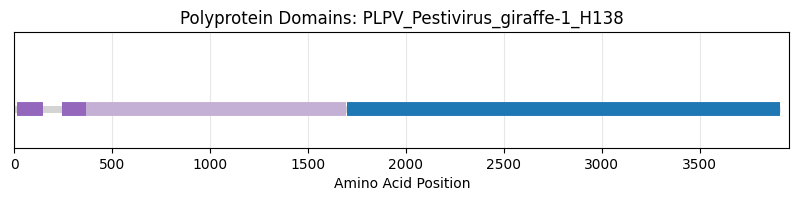

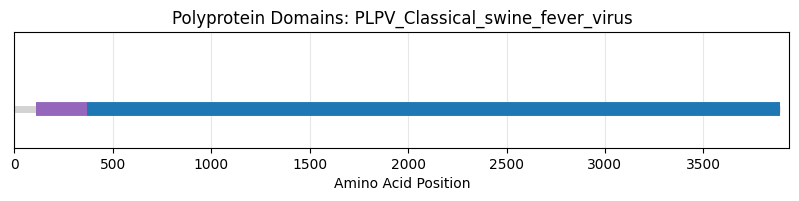

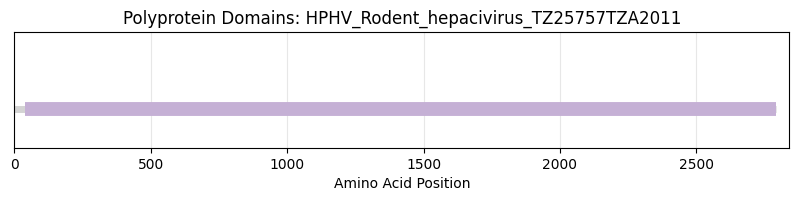

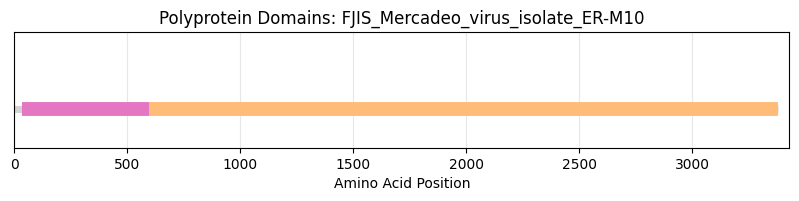

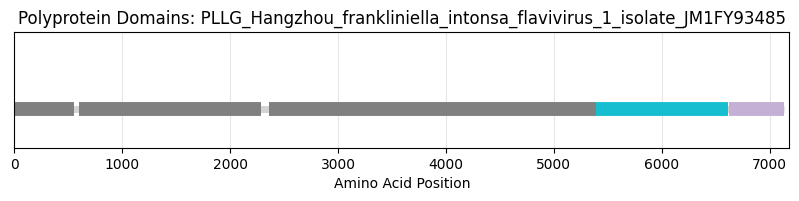

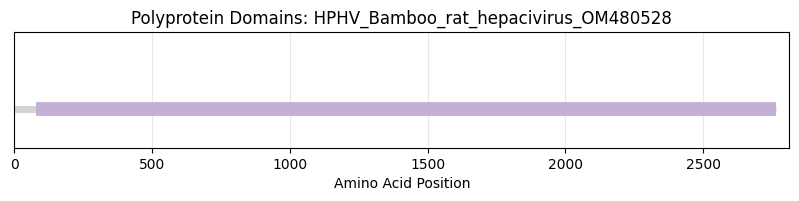

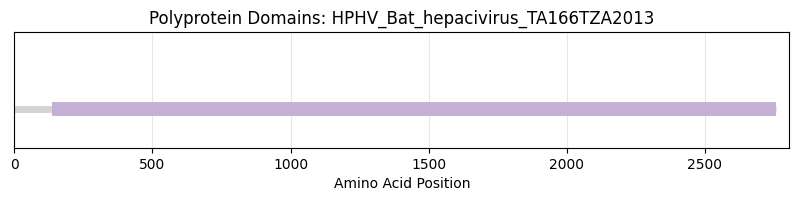

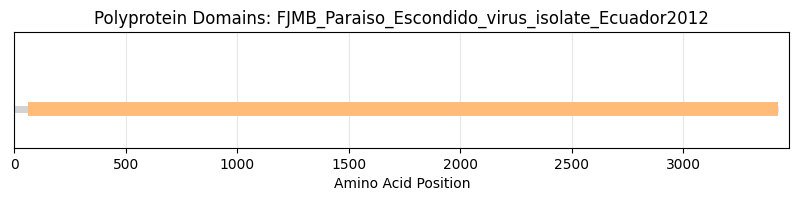

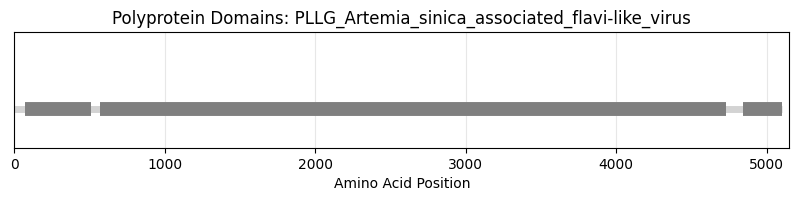

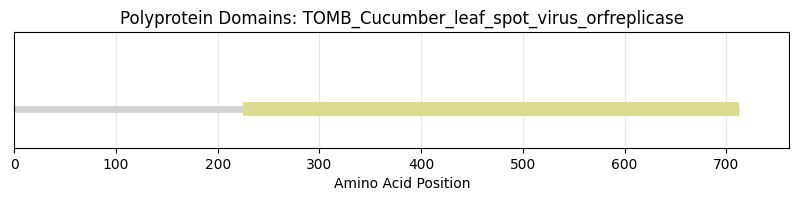

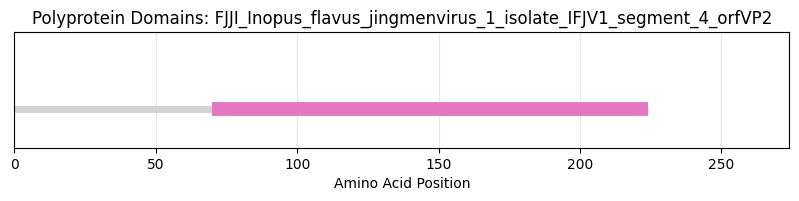

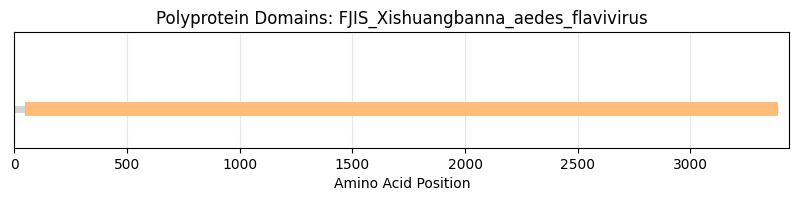

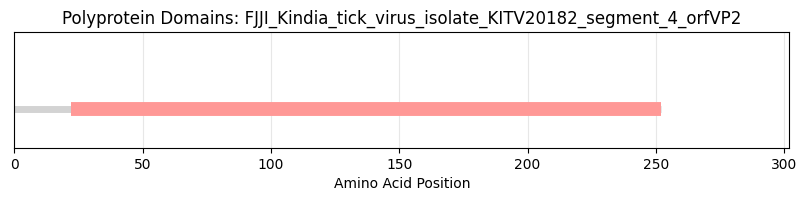

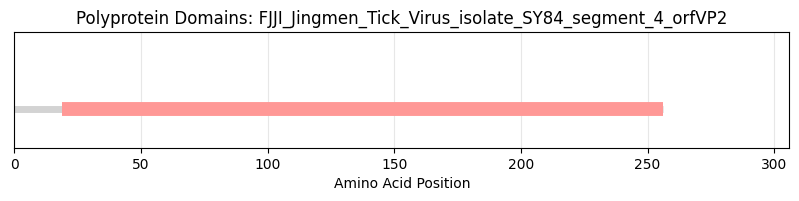

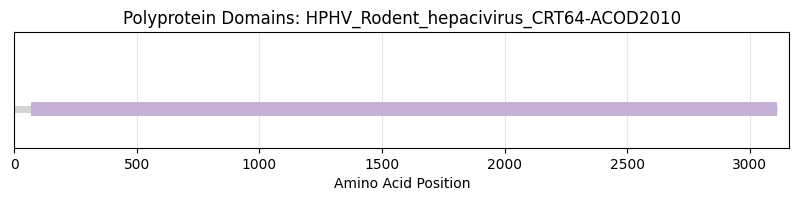

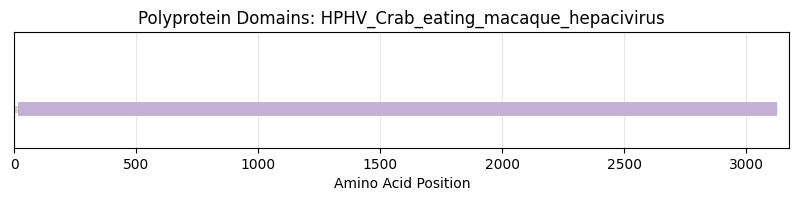

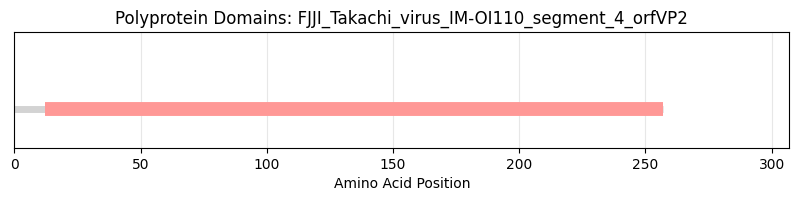

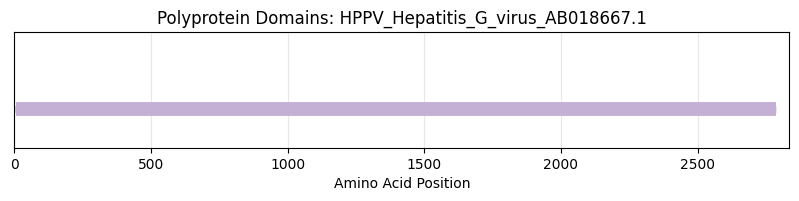

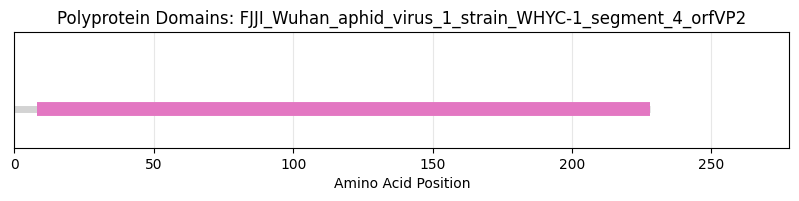

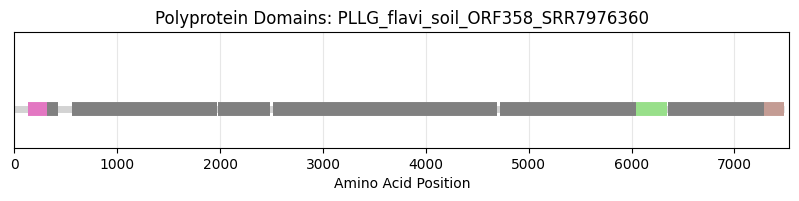

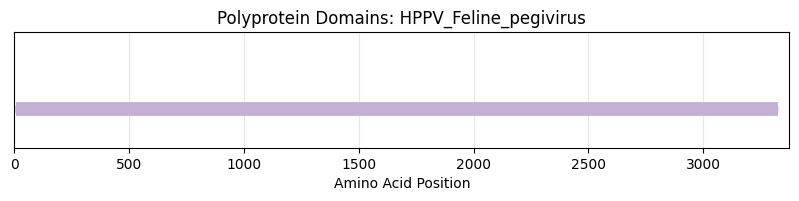

In [86]:
#visualize the clusters in a virus using the colors assigned above
#plot the domains on a linear representation of the polyprotein
def plot_polyprotein_domains(sequence_id, regions_df, domain_colors, output_file=None):
	"""
	Plot domains on a linear representation of the polyprotein.
	
	Parameters:
	- sequence_id: ID of the polyprotein sequence to plot
	- regions_df: DataFrame with domain regions
	- domain_colors: Dictionary mapping domain IDs to colors
	- output_file: If provided, save the plot to this file
	"""
	import matplotlib.pyplot as plt
	
	# Filter regions for the given sequence
	seq_regions = regions_df[regions_df['sequence_id'] == sequence_id]
	
	if seq_regions.empty:
		print(f"No regions found for sequence {sequence_id}")
		return
	
	# Determine polyprotein length
	polyprotein_length = seq_regions['end'].max()
	
	# Create plot
	plt.figure(figsize=(15, 3))
	plt.hlines(1, 0, polyprotein_length, colors='lightgray', linewidth=5)
	
	for _, row in seq_regions.iterrows():
		domain_id = f"{row['sequence_id']}_domain_{row['region_number']}"
		color = domain_colors.get(domain_id, 'gray')
		plt.hlines(1, row['start'], row['end'], colors=color, linewidth=10)
		plt.text((row['start'] + row['end']) / 2, 1.05, f"D{row['region_number']}", 
				 ha='center', va='bottom', fontsize=10, color='black')
	
	plt.title(f'Polyprotein Domains: {sequence_id}', fontsize=14)
	plt.xlabel('Amino Acid Position', fontsize=12)
	plt.yticks([])
	plt.xlim(0, polyprotein_length + 50)
	plt.ylim(0.9, 1.2)
	plt.grid(axis='x', alpha=0.3)
	
	if output_file:
		plt.savefig(output_file, bbox_inches='tight')
		print(f"Saved polyprotein domain plot to {output_file}")
	else:
		plt.show()

#make a small plot with polyprotein domains
#dont label the domains just show the colored boxes
def plot_simple_polyprotein_domains(sequence_id, regions_df, domain_colors, output_file=None):
	"""
	Plot a simple representation of the polyprotein with colored domain boxes.
	
	Parameters:
	- sequence_id: ID of the polyprotein sequence to plot
	- regions_df: DataFrame with domain regions
	- domain_colors: Dictionary mapping domain IDs to colors
	- output_file: If provided, save the plot to this file
	"""
	import matplotlib.pyplot as plt
	
	# Filter regions for the given sequence
	seq_regions = regions_df[regions_df['sequence_id'] == sequence_id]
	
	if seq_regions.empty:
		print(f"No regions found for sequence {sequence_id}")
		return
	
	# Determine polyprotein length
	polyprotein_length = seq_regions['end'].max()
	
	# Create plot
	plt.figure(figsize=(10, 1.5))
	plt.hlines(1, 0, polyprotein_length, colors='lightgray', linewidth=5)
	
	for _, row in seq_regions.iterrows():
		domain_id = f"{row['sequence_id']}_domain_{row['region_number']}"
		color = domain_colors.get(domain_id, 'gray')
		plt.hlines(1, row['start'], row['end'], colors=color, linewidth=10)
	
	plt.title(f'Polyprotein Domains: {sequence_id}', fontsize=12)
	plt.xlabel('Amino Acid Position', fontsize=10)
	plt.yticks([])
	plt.xlim(0, polyprotein_length + 50)
	plt.ylim(0.9, 1.2)
	plt.grid(axis='x', alpha=0.3)
	
	if output_file:
		plt.savefig(output_file, bbox_inches='tight')
		print(f"Saved simple polyprotein domain plot to {output_file}")
	else:
		plt.show()

#plot 5 random viral proteomes

for i in range(25):
	first_seq = random.choice(list(consensus_regions.keys()))
	plot_simple_polyprotein_domains(first_seq, regions_df, domain_colors)

In [87]:
def create_foldseek_db_from_fastas(
	aa_fasta: str,
	three_di_fasta: str,
	output_db: str,
	foldseek_bin: str = "foldseek"
) -> bool:
	"""
	Create a FoldSeek database from AA and 3Di FASTA files using TSV intermediate format.
	
	Args:
		aa_fasta: Path to amino acid FASTA
		three_di_fasta: Path to 3Di FASTA
		output_db: Path for output database (without extension)
		foldseek_bin: Path to foldseek binary
		
	Returns:
		True if successful, False otherwise
	"""
	try:
		from Bio import SeqIO
		import tempfile
		
		# Read amino acid sequences
		sequences_aa = {}
		for record in SeqIO.parse(aa_fasta, "fasta"):
			sequences_aa[record.id] = str(record.seq)
		
		# Read 3Di sequences
		sequences_3di = {}
		for record in SeqIO.parse(three_di_fasta, "fasta"):
			if record.id not in sequences_aa.keys():
				print(f"Warning: ignoring 3Di entry {record.id}, since it is not in the amino-acid FASTA file")
			else:
				sequences_3di[record.id] = str(record.seq).upper()
		
		# Validate that all AA sequences have corresponding 3Di sequences
		missing_3di = []
		for seq_id in sequences_aa.keys():
			if seq_id not in sequences_3di.keys():
				missing_3di.append(seq_id)
		
		if missing_3di:
			print(f"Error: {len(missing_3di)} entries in amino-acid FASTA have no corresponding 3Di string:")
			for seq_id in missing_3di[:5]:  # Show first 5
				print(f"  - {seq_id}")
			if len(missing_3di) > 5:
				print(f"  ... and {len(missing_3di) - 5} more")
			return False
		
		# Create temporary TSV files
		with tempfile.NamedTemporaryFile(mode='w', suffix='_aa.tsv', delete=False) as aa_tsv:
			with tempfile.NamedTemporaryFile(mode='w', suffix='_3di.tsv', delete=False) as three_di_tsv:
				with tempfile.NamedTemporaryFile(mode='w', suffix='_header.tsv', delete=False) as header_tsv:
					
					# Generate TSV content
					for i, seq_id in enumerate(sequences_aa.keys(), 1):
						aa_tsv.write(f"{i}\t{sequences_aa[seq_id]}\n")
						three_di_tsv.write(f"{i}\t{sequences_3di[seq_id]}\n")
						header_tsv.write(f"{i}\t{seq_id}\n")
					
					aa_tsv_path = aa_tsv.name
					three_di_tsv_path = three_di_tsv.name
					header_tsv_path = header_tsv.name
		
		try:
			# Create FoldSeek databases using tsv2db
			commands = [
				[foldseek_bin, "tsv2db", aa_tsv_path, output_db, "--output-dbtype", "0"],
				[foldseek_bin, "tsv2db", three_di_tsv_path, f"{output_db}_ss", "--output-dbtype", "0"],
				[foldseek_bin, "tsv2db", header_tsv_path, f"{output_db}_h", "--output-dbtype", "12"]
			]
			
			for cmd in commands:
				print(f"Running: {' '.join(cmd)}")
				result = subprocess.run(
					cmd,
					capture_output=True,
					text=True,
					check=True
				)
				
				if result.stdout:
					print(result.stdout)
				if result.stderr:
					print(result.stderr, file=sys.stderr)
			
			print(f"✓ Successfully created FoldSeek database with {len(sequences_aa)} sequences")
			return True
			
		finally:
			# Clean up temporary TSV files
			for temp_file in [aa_tsv_path, three_di_tsv_path, header_tsv_path]:
				if os.path.exists(temp_file):
					os.unlink(temp_file)
					
	except ImportError:
		print("Error: BioPython is required. Install with: pip install biopython", file=sys.stderr)
		return False
	except subprocess.CalledProcessError as e:
		print(f"Error running foldseek: {e}", file=sys.stderr)
		print(f"stdout: {e.stdout}", file=sys.stderr)
		print(f"stderr: {e.stderr}", file=sys.stderr)
		return False
	except Exception as e:
		print(f"Unexpected error: {e}", file=sys.stderr)
		return False


In [88]:
#create a tree for each domain cluster

for i, cluster in enumerate(filtered_clusters, 1):
	cluster_fasta_file = os.path.join('domain_clusters_fasta', f'cluster_{i}', f'cluster_{i}.fasta')
	db_file = os.path.join('domain_clusters_fasta', f'cluster_{i}', f'cluster_{i}_foldseek_db'
	)
	cluster_fasta_file3di = os.path.join('domain_clusters_fasta', f'cluster_{i}', f'cluster_{i}_3di.fasta')
	db_file3di = os.path.join('domain_clusters_fasta', f'cluster_{i}', f'cluster_{i}_3di_foldseek_db'
	)
	create_foldseek_db_from_fastas(cluster_fasta_file, cluster_fasta_file3di, db_file)
	print(f"Created Foldseek DB for cluster {i} at {db_file}")


Running: foldseek tsv2db /tmp/tmpke8vlvcc_aa.tsv domain_clusters_fasta/cluster_1/cluster_1_foldseek_db --output-dbtype 0
tsv2db /tmp/tmpke8vlvcc_aa.tsv domain_clusters_fasta/cluster_1/cluster_1_foldseek_db --output-dbtype 0 

MMseqs Version:           	10.941cd33
Output database type      	0
Compressed                	0
Verbosity                 	3

Output database type: Aminoacid
Time for merging to cluster_1_foldseek_db: 0h 0m 0s 0ms
Time for processing: 0h 0m 0s 1ms

Running: foldseek tsv2db /tmp/tmpxo0ejee__3di.tsv domain_clusters_fasta/cluster_1/cluster_1_foldseek_db_ss --output-dbtype 0
tsv2db /tmp/tmpxo0ejee__3di.tsv domain_clusters_fasta/cluster_1/cluster_1_foldseek_db_ss --output-dbtype 0 

MMseqs Version:           	10.941cd33
Output database type      	0
Compressed                	0
Verbosity                 	3

Output database type: Aminoacid
Time for merging to cluster_1_foldseek_db_ss: 0h 0m 0s 0ms
Time for processing: 0h 0m 0s 1ms

Running: foldseek tsv2db /tmp/tmp02vmsy

In [94]:
#run foldseek all vs all for each cluster in exhaustive mode
for i, cluster in enumerate(filtered_clusters, 1):
	db_file = os.path.join('domain_clusters_fasta', f'cluster_{i}', f'cluster_{i}_foldseek_db'
	)
	print(f"Running FoldSeek all-vs-all for cluster {i} on {db_file}")
	output_file = os.path.join('domain_clusters_fasta', f'cluster_{i}', f'cluster_{i}_allvall.csv'
	)
	cmd = [
		'foldseek', 'easy-search',
		db_file,
		db_file,
		output_file,
		'tmp',
		'--exhaustive-search',
		'--threads', '4',
		'--format-output', 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln'
	]
	print(f"Running FoldSeek all-vs-all for cluster {i}: {' '.join(cmd)}")
	subprocess.run(cmd, check=True)
	print(f"Completed FoldSeek all-vs-all for cluster {i}, results at {output_file}")


Running FoldSeek all-vs-all for cluster 1 on domain_clusters_fasta/cluster_1/cluster_1_foldseek_db
Running FoldSeek all-vs-all for cluster 1: foldseek easy-search domain_clusters_fasta/cluster_1/cluster_1_foldseek_db domain_clusters_fasta/cluster_1/cluster_1_foldseek_db domain_clusters_fasta/cluster_1/cluster_1_allvall.csv tmp --exhaustive-search --threads 4 --format-output query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln
domain_clusters_fasta/cluster_1/cluster_1_allvall.csv exists and will be overwritten
easy-search domain_clusters_fasta/cluster_1/cluster_1_foldseek_db domain_clusters_fasta/cluster_1/cluster_1_foldseek_db domain_clusters_fasta/cluster_1/cluster_1_allvall.csv tmp --exhaustive-search --threads 4 --format-output query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln 

MMseqs Version:                    	10.941cd33
Seq. id. threshold                 	0
Coverage threshold                 	0
Coverag

In [91]:
# Create domain to species mapping based on domain naming convention
# Domain names follow the format: {sequence_id}_domain_{region_number}

# Create a lookup from sequence_id to species_name
seq_to_species = dict(zip(mapping_df['sequence_id'], mapping_df['species_name']))

# Build domain_to_species mapping
domain_to_species = {}
for _, row in regions_df.iterrows():
	seq_id = row['sequence_id']
	domain_id = f"{seq_id}_domain_{row['region_number']}"
	
	if seq_id in seq_to_species:
		domain_to_species[domain_id] = seq_to_species[seq_id]
	else:
		# Fallback for any sequences not in mapping
		domain_to_species[domain_id] = 'unknown'

print(f"Created mapping for {len(domain_to_species)} domains")
print(f"Unique species: {len(set(domain_to_species.values()))}")
print("\nExample mappings:")
for domain_id, species in list(domain_to_species.items())[:5]:
	print(f"  {domain_id} -> {species}")


Created mapping for 1186 domains
Unique species: 394

Example mappings:
  FJJI_Heilongjiang_tick_virus_isolate_HLJ41_segment_4_orfVP2_domain_1 -> Heilongjiang tick
  FJIS_Culiseta_flavivirus_strain_502-13_domain_1 -> Culiseta flavivirus
  FJIS_Culiseta_flavivirus_strain_502-13_domain_2 -> Culiseta flavivirus
  FJJI_Jingmen_tick_virus_isolate_WS3_segment_2_orfVP1_domain_1 -> Jingmen tick
  FJJI_Jingmen_tick_virus_isolate_WS3_segment_2_orfVP1_domain_2 -> Jingmen tick


In [95]:
mamba install quicktree -c bioconda -y


Looking for: ['quicktree']

[+] 0.0s
bioconda/linux-64 ━━━━━━━━━╸━━━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s[+] 0.1s
bioconda/linux-64    ━━━━━━━━╸━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s
bioconda/noarch      ╸━━━━━━━━━━━━━━━╸━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s
conda-forge/linux-64 ━━━━━━━━━━━━━━╸━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s
conda-forge/noarch   ━━━━━━━━━━━━━━╸━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s[+] 0.2s
bioconda/linux-64    ━━╸━━━━━━━━━━━━━━━━━━━━ 958.1kB /   5.4MB @   6.1MB/s  0.2s
bioconda/noarch      ━━╸━━━━━━━━━━━━━━━╸━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.2s
conda-forge/linux-64 ━━━━━━━━━━━━━━━━━━━━━━━  67.6kB /  50.1MB @ 427.0kB/s  0.2s
conda-forge/noarch   ━━━━━━━━━━━━━━━━━━━━━━━  55.1kB /  24.2MB @ 347.2kB/s  0.2s[+] 0.3s
bioconda/linux-64    ━━━━━━━━━━━╸━━━━━━━━━━━   2.9MB /   5.4MB @  10.7MB/s  0.3s
bioconda/noarch      ━━━━━━━━━━━━━━━━━━━━━━━  44.1kB /   5.1MB @ 162.8kB/s  0.3s
conda-forge/linux-64 ━━━━━━━━━━━━━━━━━━━━━━━   

In [96]:
# Import/adapt functions from foldseek2tree.py for new column format
import subprocess
import shlex

def Tajima_dist(kn_ratio, bfactor=19/20, iter=100):
	"""Apply Tajima's statistical correction to a distance matrix"""
	taj = np.add.reduce([
		(kn_ratio**(np.ones(kn_ratio.shape)*i)) / (bfactor**(i-1)*i) 
		for i in range(1, iter)
	])
	np.fill_diagonal(taj, 0)
	return taj

def simple_logdist(kn_ratio, bfactor=19/20, iter=100):
	"""Simple log-based distance correction"""
	d = -bfactor * np.log(1 - (kn_ratio / bfactor))
	np.fill_diagonal(d, 0)
	return d

def distmat_to_txt(identifiers, distmat, outfile):
	"""Write distance matrix in phylip format for quicktree/fastme"""
	outstr = str(len(identifiers)) + '\n'
	for i, pdb in enumerate(identifiers):
		# Truncate/sanitize identifier (phylip format has limits)
		safe_id = pdb.replace(' ', '_')#[:50]
		outstr += safe_id + ' ' + ' '.join(["{:.6f}".format(d) for d in list(distmat[i, :])]) + '\n'
	with open(outfile, 'w') as handle:
		handle.write(outstr)
	return outfile

def runQuicktree(clusterfile, quicktreepath='quicktree'):
	"""Run quicktree on a phylip distance matrix"""
	output_tree = clusterfile + '.struct_tree.nwk'
	cmd = f'{quicktreepath} -i m {clusterfile}'
	result = subprocess.run(shlex.split(cmd), capture_output=True, text=True)
	with open(output_tree, 'w') as f:
		f.write(result.stdout)
	return output_tree

def foldseek_to_distmat(allvall_csv, metric='fident'):
	"""
	Convert FoldSeek all-vs-all results to a distance matrix.
	Adapted for new column format: query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln
	
	Parameters:
	- allvall_csv: Path to FoldSeek all-vs-all results CSV
	- metric: Column to use for similarity ('fident')
	
	Returns:
	- ids: List of sequence identifiers
	- distmat: Distance matrix (1 - similarity)
	"""
	# Read FoldSeek results
	res = pl.read_csv(allvall_csv, separator='\t', has_header=False)
	res.columns = [
		'query', 'target', 'fident', 'alnlen', 'mismatch', 'gapopen',
		'qstart', 'qend', 'tstart', 'tend', 'evalue', 'bits', 'qaln', 'taln'
	]
	
	# Get unique identifiers
	ids = list(set(res['query'].to_list() + res['target'].to_list()))
	ids = sorted(ids)
	pos = {protid: i for i, protid in enumerate(ids)}
	
	# Initialize similarity matrix
	simmat = np.zeros((len(pos), len(pos)))
	counts = np.zeros((len(pos), len(pos)))
	
	# Fill similarity matrix
	for row in res.to_dicts():
		i = pos[row['query']]
		j = pos[row['target']]
		
		# fident is already 0-100, convert to 0-1
		sim = row[metric] / 100.0 if row[metric] > 1 else row[metric]
		
		simmat[i, j] += sim
		simmat[j, i] += sim
		counts[i, j] += 1
		counts[j, i] += 1
	
	# Average similarities (handle self-alignments)
	counts = np.maximum(counts, 1)  # Avoid division by zero
	simmat /= counts
	
	# Set diagonal to 1 (self-similarity)
	np.fill_diagonal(simmat, 1.0)
	
	# Convert similarity to distance
	distmat = 1 - simmat
	
	return ids, distmat

def cluster_to_tree(allvall_csv, output_dir, cluster_name, use_tajima=True, quicktreepath='quicktree'):
	"""
	Build a phylogenetic tree from a FoldSeek all-vs-all results file.
	
	Parameters:
	- allvall_csv: Path to FoldSeek all-vs-all results CSV
	- output_dir: Directory to save output files
	- cluster_name: Name for output files
	- use_tajima: Whether to apply Tajima's statistical correction
	- quicktreepath: Path to quicktree binary
	
	Returns:
	- Path to output tree file
	"""
	# Load distance matrix
	ids, distmat = foldseek_to_distmat(allvall_csv, metric='fident')
	
	# Apply statistical correction
	if use_tajima:
		# Tajima correction for protein sequences (bfactor=0.93 for ~20 amino acids)
		distmat_corrected = Tajima_dist(distmat, bfactor=0.93, iter=100)
	else:
		distmat_corrected = simple_logdist(distmat, bfactor=0.93)
	
	# Handle any inf or nan values
	distmat_corrected = np.nan_to_num(distmat_corrected, nan=0.0, posinf=10.0, neginf=0.0)
	
	# Save distance matrix
	distmat_file = os.path.join(output_dir, f'{cluster_name}_distmat.txt')
	distmat_to_txt(ids, distmat_corrected, distmat_file)
	
	# Also save as numpy array for later use
	np.save(os.path.join(output_dir, f'{cluster_name}_distmat.npy'), distmat_corrected)
	
	# Run quicktree
	tree_file = runQuicktree(distmat_file, quicktreepath=quicktreepath)
	
	return tree_file, ids, distmat_corrected

# Generate trees for each cluster using quicktree with Tajima correction
print("Generating phylogenetic trees for each cluster using quicktree...")
cluster_trees = {}

for i, cluster in enumerate(filtered_clusters, 1):
	cluster_dir = os.path.join('domain_clusters_fasta', f'cluster_{i}')
	allvall_file = os.path.join(cluster_dir, f'cluster_{i}_allvall.csv')
	
	if os.path.exists(allvall_file):
		print(f"\nProcessing cluster {i} ({len(cluster)} domains)...")
		try:
			tree_file, ids, distmat = cluster_to_tree(
				allvall_file, 
				cluster_dir, 
				f'cluster_{i}',
				use_tajima=True,
				quicktreepath='quicktree'
			)
			cluster_trees[i] = {
				'tree_file': tree_file,
				'ids': ids,
				'distmat': distmat,
				'size': len(ids)
			}
			print(f"  ✓ Tree saved to {tree_file}")
			print(f"  ✓ {len(ids)} sequences in tree")
		except Exception as e:
			print(f"  ✗ Error processing cluster {i}: {e}")
			import traceback
			traceback.print_exc()
	else:
		print(f"\nCluster {i}: All-vs-all file not found at {allvall_file}")

print(f"\n{'='*60}")
print(f"✓ Successfully generated trees for {len(cluster_trees)} clusters")

Generating phylogenetic trees for each cluster using quicktree...

Processing cluster 1 (34 domains)...
  ✓ Tree saved to domain_clusters_fasta/cluster_1/cluster_1_distmat.txt.struct_tree.nwk
  ✓ 34 sequences in tree

Processing cluster 2 (30 domains)...
  ✓ Tree saved to domain_clusters_fasta/cluster_2/cluster_2_distmat.txt.struct_tree.nwk
  ✓ 30 sequences in tree

Processing cluster 3 (35 domains)...
  ✓ Tree saved to domain_clusters_fasta/cluster_3/cluster_3_distmat.txt.struct_tree.nwk
  ✓ 35 sequences in tree

Processing cluster 4 (148 domains)...
  ✓ Tree saved to domain_clusters_fasta/cluster_4/cluster_4_distmat.txt.struct_tree.nwk
  ✓ 148 sequences in tree

Processing cluster 5 (18 domains)...
  ✓ Tree saved to domain_clusters_fasta/cluster_5/cluster_5_distmat.txt.struct_tree.nwk
  ✓ 18 sequences in tree

Processing cluster 6 (4 domains)...
  ✓ Tree saved to domain_clusters_fasta/cluster_6/cluster_6_distmat.txt.struct_tree.nwk
  ✓ 4 sequences in tree

Processing cluster 7 (43 do

In [115]:
#visualize the trees with toytree
import toytree
import toyplot

for i, cluster_info in cluster_trees.items():
	tree_file = cluster_info['tree_file']
	print(f"\nVisualizing tree for cluster {i} from {tree_file}...")
	
	# Load tree
	try:
		tree = toytree.tree(tree_file)
		
		# Draw the tree
		tree.draw(
			node_labels=False,
			edge_colors="black",
			width=600,
			height=2000,			
		)
		
		
	except Exception as e:
		print(f"  ✗ Error visualizing tree for cluster {i}: {e}")


Visualizing tree for cluster 1 from domain_clusters_fasta/cluster_1/cluster_1_distmat.txt.struct_tree.nwk...

Visualizing tree for cluster 2 from domain_clusters_fasta/cluster_2/cluster_2_distmat.txt.struct_tree.nwk...

Visualizing tree for cluster 3 from domain_clusters_fasta/cluster_3/cluster_3_distmat.txt.struct_tree.nwk...

Visualizing tree for cluster 4 from domain_clusters_fasta/cluster_4/cluster_4_distmat.txt.struct_tree.nwk...

Visualizing tree for cluster 5 from domain_clusters_fasta/cluster_5/cluster_5_distmat.txt.struct_tree.nwk...

Visualizing tree for cluster 6 from domain_clusters_fasta/cluster_6/cluster_6_distmat.txt.struct_tree.nwk...

Visualizing tree for cluster 7 from domain_clusters_fasta/cluster_7/cluster_7_distmat.txt.struct_tree.nwk...

Visualizing tree for cluster 8 from domain_clusters_fasta/cluster_8/cluster_8_distmat.txt.struct_tree.nwk...

Visualizing tree for cluster 9 from domain_clusters_fasta/cluster_9/cluster_9_distmat.txt.struct_tree.nwk...

Visualizi

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="600.0px" height="2000.0px" viewBox="0 0 600.0 2000.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t6bb2ebf90e434e4fa81d631dffd6cd95"> PLPV_Bovine_viral_diarrhea_virus_3_Th04_KhonKaen_domain_2 PLPV_Tunisian_small_ruminant_pestivirus_strain_920192007AG_domain_1 PLPV_Pestivirus_sp._isolate_ovineIt338710-32017_domain_2 PLPV_Classical_swine_fever_virus_domain_2 PLPV_Pestivirus_strain_Aydin04-TR_domain_2 PLPV_Pestivirus_Burdur05-TR_domain_2 PLPV_Pestivirus_reindeer-1_V60-Krefeld_domain_2 PLPV_Border_disease_virus_X818_domain_1 PLPV_Zikole_virus_domain_2 PLPV_Bat_pestivirus_BtSk-PestV-1GX2017_domain_1 PLPV_Atypical_porcine_pestivirus_domain_2 PLPV_Glass_knifefish_pestivirus_domain_1 PLPV_Frog_pestivirus_domain_1 PLPV_Rodent_pestivirus_isolate_RtNn-PestVHuB2014_domain_1 PLPV_Norway_rat_pestivirus_isolate_NrPVNYC-D23_domain_1 PLPV_Rodent_pestivirus_isolate_RtAp-PestVJL2014_domain_2 PLPV_Jingmen_Crocidura_shantungensis_pestivirus_1_domain_2 PLPV_Wenzhou_Pipistrellus_abramus_pestivirus_1_isolate_YJB_Pabr_domain_3 PLPV_Linda_virus_strain_Austria1_domain_2 PLPV_Porcine_pestivirus_isolate_Bungowannah_domain_2 PLPV_Phocoena_pestivirus_isolate_NS170386_domain_2 PLPV_Pangolin_pestivirus_strain_PPeVBIME7P022Tpangolin2018_domain_3 PLPV_Pangolin_pestivirus_strain_PPeVBIME6P226Tpangolin2018_domain_1 PLPV_Pangolin_pestivirus_strain_PPeVBIME6P141Tpangolin2018_domain_1 PLPV_Pangolin_pestivirus_strain_PPeVBIME5P141Tpangolin2018_domain_1 PLPV_Pangolin_pestivirus_strain_PPeVBIME3P019Tpangolin2018_domain_1 PLPV_Dongyang_pangolin_virus_isolate_DYCS_domain_1 PLPV_Pangolin_pestivirus_strain_PPeVBIME1P019Tpangolin2018_domain_1 PLPV_Pangolin_pestivirus_1_isolate_ZJ-F1_domain_1 PLPV_Pronghorn_antelope_pestivirus_domain_3 PLPV_Pestivirus_giraffe-1_H138_domain_4 PLPV_Pestivirus_PG-2_domain_2 PLPV_Bovine_viral_diarrhea_virus_2_domain_2 PLPV_Bovine_viral_diarrhea_virus_1_domain_1

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="600.0px" height="2000.0px" viewBox="0 0 600.0 2000.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="tbf1483c4fe8141e5b07d558fd70157a8"> PLLG_Flaviviridae_sp._isolate_TIGMIC_13_domain_4 PLLG_Flaviviridae_sp._isolate_TIGMIC_36_domain_4 PLLG_Flaviviridae_sp._isolate_TIGMIC_24_domain_3 PLLG_Flaviviridae_sp._isolate_TIGMIC_12_domain_3 PLLG_Bole_tick_virus_4_strain_NE-ShL2_domain_4 PLLG_Zhangjiakou_Flavi_tick_virus_1_domain_3 PLLG_Flaviviridae_sp._isolate_TIGMIC_39_domain_3 PLLG_Flaviviridae_sp._isolate_TIGMIC_38_domain_3 PLLG_Flaviviridae_sp._strain_FVHAHH8_domain_3 PLLG_Trinbago_virus_isolate_TTP-Pool-4_domain_3 PLLG_Rhipicephalus_sanguineus_associated_flavi-like_virus_domain_4 PLLG_Bole_tick_virus_4_isolate_TIGMIC_1_domain_5 PLLG_Bole_tick_virus_4_isolate_Thailand_tick_flavivirus_domain_3 PLLG_Camel_tick_virus_isolate_Alain_domain_4 PLLG_Bole_tick_virus_4_strain_BangaliH.truncatum2018_domain_4 PLLG_Bole_tick_virus_4_isolate_TIGMIC_2_domain_4 PLLG_Bole_tick_virus_4_strain_BLP-1_domain_3 PLLG_Bole_tick_virus_4_isolate_GSC346flaviV_domain_4 PLLG_Bole_tick_virus_4_strain_IftinH.dromedarii2018_domain_4 PLLG_Haseki_tick_virus_strain_Novosibirsk-2020_domain_3 PLLG_Dermacentor_reticulatus_pestivirus-like_virus_1_isolate_CT2_domain_3 PLLG_Flaviviridae_sp._isolate_TIGMIC_8_domain_3 PLLG_Flaviviridae_sp._isolate_TIGMIC_1_domain_3 PLLG_Flaviviridae_sp._isolate_TIGMIC_5_domain_3 PLLG_Flaviviridae_sp._isolate_TIGMIC_30_domain_3 PLLG_Flaviviridae_sp._isolate_TIGMIC_20_domain_4 PLLG_Bole_tick_virus_4_strain_NE-DH2_domain_4 PLLG_Flaviviridae_sp._isolate_TIGMIC_27_domain_3 PLLG_Flaviviridae_sp._isolate_TIGMIC_28_domain_3 PLLG_Flaviviridae_sp._isolate_TIGMIC_25_domain_4

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="600.0px" height="2000.0px" viewBox="0 0 600.0 2000.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="ta69f8cdb92b245339e92aa5f39e635fe"> HPHV_Wufeng_Niviventer_fulvescens_hepacivirus_1_domain_1 HPHV_Rodent_hepacivirus_TA498-CTZA2013_domain_1 HPHV_Rodent_hepacivirus_TA085TZA2013_domain_1 HPHV_Rodent_hepacivirus_CRT382COD2010_domain_1 HPHV_Rodent_hepacivirus_MOZ329-CMOZ2011_domain_1 HPHV_Wufeng_Typhlomys_cinereus_hepacivirus_3_domain_1 HPHV_Gerbil_hepacivirus_domain_1 PLUN_flavi_soil_ORF389_SRR11565438_domain_2 HPPV_Phaiomys_leucurus_pegivirus_domain_1 PLLG_Bole_tick_virus_4_isolate_TIGMIC_1_domain_7 PLLG_Bole_tick_virus_4_strain_BangaliH.truncatum2018_domain_6 HPHV_Viviparous_lizard_hepacivirus_domain_1 HPPV_Bat_pegivirus_PDB-1734_domain_1 PLLG_Sanxia_water_strider_virus_6_strain_SYSZZ-2_domain_7 HPPV_Phaiomys_leucurus_pegivirus_domain_2 HPHV_Jingmen_Rhinolophus_sinicus_hepacivirus_domain_1 HPHV_Equine_hepacivirus_domain_1 HPHV_Non-primate_hepacivirus_NZP1_domain_1 HPHV_Non-primate_hepacivirus_strain_CU_isolate_III_domain_1 HPHV_Hepacivirus_horseDH1HUN2013_domain_1 HPHV_Recombinant_Hepacivirus_domain_1 HPPV_Rodent_pegivirus_isolate_CC61_domain_1 HPHV_Cyprichromis_hepacivirus_domain_1 HPHV_Chaetodon_aureofaciatus_hepacivirus_isolate_F25_domain_1 HPHV_Rodent_hepacivirus_TA498-ATZA2013_domain_1 HPHV_Rodent_hepacivirus_CRT490-BCOD2010_domain_1 HPHV_Rodent_hepacivirus_TA142TZA2013_domain_1 HPHV_Hepacivirus_J_isolate_Hepacivirus_RMU10-3382GER2010_domain_1 HPHV_Hepatitis_C_virus_genotype_6_domain_1 HPHV_Hepacivirus_M_domain_1 HPUN_Wenling_moray_eel_hepacivirus_domain_1 HPHV_Nanhai_dogfish_shark_hepacivirus_domain_1 HPHV_Sigmodontinae_hepacivirus_domain_1 HPHV_Rodent_hepacivirus_CRT682COD2010_domain_1 HPHV_Hepacivirus_P_domain_1

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="600.0px" height="2000.0px" viewBox="0 0 600.0 2000.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="tdbce2ba7cf714e8aa4dd85e4b2949962"> FJMB_Naranjal_virus_strain_25008_domain_2 FJMB_Bussuquara_virus_domain_1 FJMB_Iguape_virus_strain_SPAn_71686_domain_1 FJMB_Aroa_virus_strain_Macaray_01809_domain_1 FJMB_Torres_virus_strain_TS5273_domain_1 FJMB_Stratford_virus_isolate_22911_domain_2 FJMB_Kokobera_virus_domain_1 FJMB_Bainyik_virus_strain_MK7979_domain_1 FJMB_New_Mapoon_virus_domain_2 FJUN_flavi_freshwater_ORF52_SRR12063566_orf_2_domain_1 FJIS_Xishuangbanna_aedes_flavivirus_domain_1 FJIS_Menghai_flavivirus_isolate_MHAedFV1_domain_2 FJIS_Kilpisjarvi_flavivirus_isolate_FINL-201890_domain_1 FJIS_Ochlerotatus_scapularis_flavivirus_bvmq18-25_domain_2 FJIS_Kamiti_River_virus_domain_2 FJIS_Cell_fusing_agent_virus_strain_2_domain_1 FJIS_Cell_fusing_agent_virus_domain_2 FJIS_Aedes_flavivirus_strain_Bangkok_domain_2 FJIS_Aedes_flavivirus_strain_AEFV-SPFLD-MO-2011-MP6_domain_2 FJIS_Aedes_flavivirus_AEFVMQ29Bogor2017_domain_2 FJIS_Parramatta_River_virus_isolate_92-B115745_domain_2 FJIS_Ochlerotatus_caspius_flavivirus_isolate_1608_domain_2 FJIS_Hanko_virus_domain_1 FJIS_Tafomo_virus_strain_TVB22-CI-2004_domain_2 FJIS_Culex_theileri_flavivirus_domain_2 FJIS_Culex_theileri_flavivirus_RP-2011_domain_2 FJIS_Quang_Binh_virus_isolate_JM17156China2017_domain_2 FJIS_Quang_Binh_virus_domain_2 FJIS_Mosquito_flavivirus_isolate_LSFlaviV-A20-09_domain_2 FJIS_Mosquito_flavivirus_YDFVOct2013_domain_2 FJIS_Culex_flavivirus_domain_2 FJIS_Palm_Creek_virus_isolate_56_domain_1 FJIS_Nakiwogo_virus_strain_Uganda08_domain_1 FJIS_Nienokoue_virus_isolate_B51CI2004_domain_2 FJIS_Mac_Peak_virus_isolate_McPV_150840_domain_1 FJIS_Karumba_virus_isolate_KRBV_Kim1_domain_1 FJIS_Anopheles_flavivirus_variant_1_domain_1 FJIS_Sabethes_flavivirus_isolate_Ms42_domain_1 FJIS_Culex_Flavi-like_virus_strain_CFVLSan_Francisco_domain_2 FJIS_Calbertado_virus_isolate_CMS001_032_ALCO_domain_1 FJIS_Calbertado_virus_isolate_44-13_domain_1 FJIS_Mercadeo_virus_isolate_ER-M10_domain_2 FJIS_Culiseta_flavivirus_strain_502-13_domain_2 FJIS_Mansonia_flavivirus_bvmq18-1_domain_2 FJIS_Tabanus_rufidens_flavivirus_18HF18_domain_2 FJUN_XiangYun_flavivirus_isolate_XY61577_orf_2_domain_1 FJFL_Wenzhou_shark_flavivirus_strain_WZSS16343_orf_2_domain_1 FJFL_Waxsystermes_virus_domain_1 FJFL_Embiopteran_flavi-related_virus_isolate_OKIAV324_domain_1 FJFL_Tamana_bat_virus_isolate_P3_Vero_domain_2 FJFL_Cyclopterus_lumpus_virus_isolate_R170217-6L_orf_2_domain_1 FJFL_Southern_pygmy_squid_flavivirus_isolate_201405_domain_1 FJFL_Flavivirus_sp._isolate_sequence_91_orf_2_domain_1 FJFL_Salmon_flavivirus_strain_Davis_UGA_orf_2_domain_1 FJFL_African_cichlid_flavi_like_virus_domain_2 FJAF_Harrimaniidae_flavivirus_domain_1 FJAF_Cnidaria_flavivirus_domain_1 FJAF_Gammarus_pulex_flavivirus_isolate_GPCM_orf_2_domain_1 FJAF_Sea_firefly_flavivirus_orf_2_domain_1 FJAF_Photeros_flavivirus_orf_2_domain_1 FJAF_Crangon_crangon_flavivirus_orf_2_domain_1 FJAF_Gammarus_chevreuxi_flavivirus_isolate_100_1_orf_2_domain_1 FJUN_Mpulungu_flavivirus_ZT17-1078_domain_1 FJTB_Tyuleniy_virus_strain_LEIV-6C_domain_1 FJTB_Saumarez_Reef_virus_isolate_W11_2232_domain_1 FJTB_Meaban_virus_domain_1 FJTB_Kama_virus_strain_LEIV-20776Tat_domain_1 FJTB_Turkish_sheep_encephalitis_virus_domain_2 FJTB_Tick-borne_encephalitis_virus_domain_1 FJTB_Spanish_sheep_encephalitis_virus_domain_1 FJTB_Louping_ill_virus_isolate_IRE_IRE2_1971_domain_1 FJTB_Omsk_hemorrhagic_fever_virus_strain_Bogolubovka1048_domain_1 FJTB_Langat_virus_domain_1 FJTB_Kyasanur_forest_diseas

...

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="600.0px" height="2000.0px" viewBox="0 0 600.0 2000.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="tdaef263adeb0453fb9ec9d5c45847dd2"> FJJI_Trichopteran_jingmen-related_virus_isolate_OKIAV337_segment_2_orfVP1_domain_1 FJJI_Dipteran_jingmen-related_virus_isolate_OKIAV332_segment_2_orfVP1_domain_1 FJJI_Wuhan_aphid_virus_1_strain_WHYC-1_segment_2_orfVP1_domain_1 FJJI_Wuhan_flea_virus_strain_WHZM_segment_2_orfVP1_domain_1

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="600.0px" height="2000.0px" viewBox="0 0 600.0 2000.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="td4cb648a2ac44d3f819089a10db1fd81"> PLLG_Brachymeria_lasus_associated_flavi-like_virus_domain_2 PLLG_Shuangao_lacewing_virus_2_strain_SCL_domain_3 PLLG_Gamboa_mosquito_virus_strain_GW_domain_4 PLLG_Xiangshan_flavi-like_virus_2_domain_2 PLLG_Fushun_laodelphax_striatellus_flavivirus_1_isolate_HFSFS147_orf_1_domain_5

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="600.0px" height="2000.0px" viewBox="0 0 600.0 2000.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t300ba70e6ee041e79f6b408314af9481"> PLLG_Insect_associated_flavi-like_virus_domain_6 PLLG_Sanxia_water_strider_virus_6_strain_SYSZZ-2_domain_12 PLLG_Sonchus_asper_flavi-like_virus_domain_9 PLLG_Lampyris_noctiluca_flavivirus_1_isolate_17FIN1_domain_4 FJMB_Torres_virus_strain_TS5273_domain_2 FJMB_T_Ho_virus_strain_T_Ho-Mex07_domain_3 FJMB_Panmunjeom_flavivirus_strain_A12.3025ROK2012_domain_2 PLLG_Carrot_flavi-like_virus_1_isolate_744_domain_10 PLLG_Gentian_Kobu-sho-associated_virus_domain_8 PLLG_Coptis_teeta_flavi-like_virus_domain_11 PLLG_Phenacoccus_solenopsis_associated_flavi-like_virus_domain_7 PLLG_Hangzhou_frankliniella_intonsa_flavivirus_2_isolate_JM1FY91827_domain_6 PLLG_Frankliniella_occidentalis_flavi-like_virus_1_domain_7 PLLG_Hangzhou_frankliniella_intonsa_flavivirus_1_isolate_JM1FY93485_domain_6 PLLG_Apis_flavivirus_isolate_RI-A_domain_7

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="600.0px" height="2000.0px" viewBox="0 0 600.0 2000.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t7cd89f9330ad4e06a944902f3c2c9b5c"> FJMB_Yokose_virus_domain_1 FJMB_Sokoluk_virus_strain_LEIV-400K_domain_1 FJMB_Yellow_fever_virus_domain_1 FJMB_Wesselsbron_virus_strain_SAH177_domain_1 FJMB_Fitzroy_River_Virus_strain_K73884_domain_2 FJMB_Sepik_virus_domain_1 FJMB_Wesselsbron_virus_strain_SAH177_domain_2 FJNV_Rio_Bravo_virus_strain_M64_domain_1 FJNV_Modoc_virus_domain_2 FJNV_Montana_myotis_leukoencephalitis_virus_domain_1 PLPV_Pangolin_pestivirus_strain_PPeVBIME7P022Tpangolin2018_domain_2 PLLG_flavi_soil_ORF358_SRR7976360_domain_1 HPHV_Xiamen_guitarfish_hepacivirus_domain_1 FJMB_West_Nile_virus_lineage_2_domain_1 FJUN_XiangYun_flavivirus_isolate_XY61577_orf_1_domain_1 HPHV_Western_African_lungfish_hepacivirus_domain_2 HPHV_Western_African_lungfish_hepacivirus_domain_1 HPHV_Gecko_hepacivirus_domain_1 HPHV_Catfish_hepacivirus_domain_1 FJAF_Gammarus_chevreuxi_flavivirus_isolate_100_1_orf_1_domain_1 FJMB_Bamaga_virus_isolate_CY4270_domain_1 FJUN_flavi_lake_water_ORF115_SRR6435398_orf_1_domain_1 FJFL_Salmon_flavivirus_strain_Davis_UGA_orf_1_domain_1 FJTB_Turkish_sheep_encephalitis_virus_domain_1 FJMB_Bouboui_virus_strain_DAK_AR_B490_domain_1 FJMB_New_Mapoon_virus_domain_1 FJJI_Wuhan_flea_virus_strain_WHZM_segment_4_orfVP2_domain_1 FJJI_Wuhan_aphid_virus_2_strain_WHYC-2_segment_4_orfVP2_domain_1 FJJI_Inopus_flavus_jingmenvirus_1_isolate_IFJV1_segment_4_orfVP2_domain_1 FJJI_Guaico_Culex_virus_isolate_LO35_segment_3_orfVP3_domain_1 FJJI_Dipteran_jingmen-related_virus_isolate_OKIAV332_segment_4_orfVP2_domain_1 FJJI_Wuhan_aphid_virus_1_strain_WHYC-1_segment_4_orfVP2_domain_1 FJJI_Trichopteran_jingmen-related_virus_isolate_OKIAV337_segment_4_orfVP3_domain_1 FJFL_African_cichlid_flavi_like_virus_domain_1 FJAF_Gammarus_chevreuxi_flavivirus_isolate_100_1_orf_1_domain_2 FJMB_Naranjal_virus_strain_25008_domain_1 PLLG_Atrato_Flavi-like_virus_1_strain_Cx_1773-1_domain_6 FJNV_Modoc_virus_domain_1 FJMB_Dengue_virus_3_domain_1 FJJI_Mole_Culex_virus_16GH38_segment_3_orfVP1_domain_1 FJMB_Fitzroy_River_Virus_strain_K73884_domain_1 FJMB_Stratford_virus_isolate_22911_domain_1 FJMB_Kampung_Karu_virus_isolate_SWK_P44_domain_1 FJMB_Chinese_soft-shelled_turtle_flavivirus_isolate_HZ-2017_domain_1 FJMB_Murray_Valley_encephalitis_virus_domain_1 FJMB_T_Ho_virus_strain_T_Ho-Mex07_domain_1 FJMB_Alfuy_virus_strain_MRM3929_domain_1 FJMB_Nounane_virus_domain_1 FJMB_Chaoyang_virus_domain_1 FJAF_Sea_firefly_flavivirus_orf_1_domain_1 FJAF_Photeros_flavivirus_orf_1_domain_2 FJAF_Crangon_crangon_flavivirus_orf_1_domain_1 FJMB_Psorophora_flavivirus_bvmq18-51_domain_1 FJMB_Murray_Valley_encephalitis_virus_domain_2 FJMB_Alfuy_virus_strain_MRM3929_domain_2 FJMB_Ilheus_virus_strain_BrMS-MQ10_domain_1

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="600.0px" height="2000.0px" viewBox="0 0 600.0 2000.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t00101e75fe1c447d9b402070583d0743"> FJAF_Gammarus_pulex_flavivirus_isolate_GPCM_orf_1_domain_2 FJAF_Sea_firefly_flavivirus_orf_1_domain_2 FJAF_Photeros_flavivirus_orf_1_domain_3 FJFL_Salmon_flavivirus_strain_Davis_UGA_orf_1_domain_2 FJAF_Gammarus_chevreuxi_flavivirus_isolate_100_1_orf_1_domain_4

In [ ]:
#create an aster compatible tree with a species_name_A for each cluster
from ete3 import Tree
import string

def get_letter_suffix(index):
	"""Convert index to letter suffix: 0->A, 1->B, ..., 25->Z, 26->AA, etc."""
	if index < 26:
		return string.ascii_uppercase[index]
	else:
		# For more than 26, use AA, AB, etc.
		first = index // 26 - 1
		second = index % 26
		if first < 0:
			return string.ascii_uppercase[second]
		return string.ascii_uppercase[first] + string.ascii_uppercase[second]

def convert_tree_to_aster_format(tree_file, output_file, domain_to_species):
	"""
	Convert a newick tree to ASTER-compatible format.
	Renames leaves from domain IDs to species_name_X format using species metadata.
	
	Parameters:
	- tree_file: Path to input newick tree
	- output_file: Path to output aster-compatible newick tree
	- domain_to_species: Dictionary mapping domain IDs to species names
	
	Returns:
	- Dictionary mapping original names to new names
	"""
	# Load tree
	try:
		t = Tree(tree_file, format=1)
	except:
		# Try other newick formats
		t = Tree(tree_file, format=0)
	
	# Group leaves by species
	species_counts = {}
	name_mapping = {}
	
	for leaf in t.iter_leaves():
		original_name = leaf.name
		
		# Get species from mapping
		if original_name not in domain_to_species:
			print(f"Warning: {original_name} not found in domain mapping, skipping")
			continue
			
		species = domain_to_species[original_name].lower()
		species = species.replace(' ', '_')  # Sanitize species name
		#remove punctiation
		species = species.replace( '.' , '')
		species = species.replace( '-' , '')
		#only allow one underscore in a name
		while species.count('_') > 1:
			species = species.replace( '_' , '', 1)		
		# Count occurrences of this species
		if species not in species_counts:
			species_counts[species] = 0
		
		# Create new name with letter suffix
		letter = get_letter_suffix(species_counts[species])
		new_name = f"{species}_{letter}"
		
		species_counts[species] += 1
		name_mapping[original_name] = new_name
		
		# Rename the leaf
		leaf.name = new_name
	
	# Write output tree
	t.write(outfile=output_file, format=5)
	
	return name_mapping, t


# Use the domain_to_species mapping created earlier
print(f"Using domain to species mapping with {len(domain_to_species)} domains")
print(f"Unique species in mapping: {len(set(domain_to_species.values()))}")

# Convert all cluster trees to ASTER format
print("\nConverting cluster trees to ASTER-compatible format...")
aster_trees = {}

for i, cluster in enumerate(filtered_clusters, 1):
	cluster_dir = os.path.join('domain_clusters_fasta', f'cluster_{i}')
	tree_file = os.path.join(cluster_dir, f'cluster_{i}_distmat.txt.struct_tree.nwk')
	aster_tree_file = os.path.join(cluster_dir, f'cluster_{i}_aster.nwk')
	
	if os.path.exists(tree_file):
		print(f"\nProcessing cluster {i}...")
		try:
			name_mapping, tree = convert_tree_to_aster_format(tree_file, aster_tree_file, domain_to_species)
			
			# Count unique species
			species_set = set()
			for orig, new in name_mapping.items():
				species = new.rsplit('_', 1)[0]
				species_set.add(species)
			
			aster_trees[i] = {
				'tree_file': aster_tree_file,
				'name_mapping': name_mapping,
				'n_leaves': len(name_mapping),
				'n_species': len(species_set)
			}
			print(f"  ✓ ASTER tree saved to {aster_tree_file}")
			print(f"  ✓ {len(name_mapping)} leaves, {len(species_set)} unique species")
			
			aster_trees[i]['aster_format'] = aster_tree_file	
			# Show example mappings
			examples = list(name_mapping.items())[:3]
			for orig, new in examples:
				print(f"    {orig} -> {new}")
			if len(name_mapping) > 3:
				print(f"    ... and {len(name_mapping) - 3} more")
				
		except Exception as e:
			print(f"  ✗ Error processing cluster {i}: {e}")
			import traceback
			traceback.print_exc()
	else:
		print(f"\nCluster {i}: Tree file not found at {tree_file}")

print(f"\n{'='*60}")
print(f"✓ Successfully converted {len(aster_trees)} cluster trees to ASTER format")

# Save all ASTER trees to a single file for running ASTER
all_aster_trees_file = 'domain_clusters_fasta/all_cluster_trees_aster.nwk'
with open(all_aster_trees_file, 'w') as f:
	for i in sorted(aster_trees.keys()):
		tree_file = aster_trees[i]['aster_format']
		with open(tree_file, 'r') as tf:
			tree_str = tf.read().strip()
			f.write(tree_str + '\n')

print(f"\n✓ All ASTER trees concatenated to {all_aster_trees_file}")

Using domain to species mapping with 1186 domains
Unique species in mapping: 394

Converting cluster trees to ASTER-compatible format...

Processing cluster 1...
  ✓ ASTER tree saved to domain_clusters_fasta/cluster_1/cluster_1_aster.nwk
  ✓ 34 leaves, 26 unique species
    PLPV_Bovine_viral_diarrhea_virus_3_Th04_KhonKaen_domain_2 -> bovineviral_diarrhea_A
    PLPV_Tunisian_small_ruminant_pestivirus_strain_920192007AG_domain_1 -> tunisiansmallruminant_pestivirus_A
    PLPV_Pestivirus_sp._isolate_ovineIt338710-32017_domain_2 -> pestivirus_sp_A
    ... and 31 more

Processing cluster 2...
  ✓ ASTER tree saved to domain_clusters_fasta/cluster_2/cluster_2_aster.nwk
  ✓ 30 leaves, 8 unique species
    PLLG_Flaviviridae_sp._isolate_TIGMIC_13_domain_4 -> flaviviridae_sp_A
    PLLG_Flaviviridae_sp._isolate_TIGMIC_36_domain_4 -> flaviviridae_sp_B
    PLLG_Flaviviridae_sp._isolate_TIGMIC_24_domain_3 -> flaviviridae_sp_C
    ... and 27 more

Processing cluster 3...
  ✓ ASTER tree saved to domain_

In [ ]:
# Run ASTRAL to infer species tree from gene trees
import subprocess

astral_output = './astral_species_tree.nwk'
astral_log = './astral.log'

# Run astral-pro3
cmd = f'astral4 -o {astral_output} {all_aster_trees_file} 2>{astral_log}'
print(f"Running ASTRAL: {cmd}")

result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

if result.returncode == 0:
	print(f"✓ ASTRAL completed successfully")
	print(f"  Species tree saved to: {astral_output}")
	print(f"  Log saved to: {astral_log}")
	
	# Read and display the species tree
	with open(astral_output, 'r') as f:
		species_tree = f.read().strip()
	print(f"\nSpecies tree ({len(species_tree)} characters):")
	print(species_tree[:500] + "..." if len(species_tree) > 500 else species_tree)
else:
	print(f"✗ ASTRAL failed with return code {result.returncode}")
	print(f"stdout: {result.stdout}")
	print(f"stderr: {result.stderr}")
	
	# Try to read the log file for more details
	if os.path.exists(astral_log):
		with open(astral_log, 'r') as f:
			log_content = f.read()
		print(f"\nLog file contents:\n{log_content[:1000]}")

Running ASTRAL: astral4 -o ./astral_species_tree.nwk domain_clusters_fasta/all_cluster_trees_aster.nwk 2>./astral.log
✓ ASTRAL completed successfully
  Species tree saved to: ./astral_species_tree.nwk
  Log saved to: ./astral.log

Species tree (23506 characters):
(((((((pestivirus_sp_A:0,rhizomyspruinosus_hepacivirus_A:0)0.333333:0,classicalswine_fever_A:0.082872)0.666667:0.0163112,tunisiansmallruminant_pestivirus_A:0.0778376)0.666667:0.0224871,((pestivirus_burdur05tr_A:0.258034,locustamigratoriaassociated_flavilike_A:1.55673)0.666667:0.842669,pestivirus_A:0.104218)0.44801:0.0263307)0.741537:0.0906114,(pestivirusreindeer1_v60krefeld_A:0.0634496,border_disease_A:0.0643109)0.666667:0.045883)0.604276:0.0726594,((((bovineviral_diarrhea_C:0,bovineviral_diarrh...


In [147]:
#load and print tree with ete3
from ete3 import Tree
species_tree_file = './astral_species_tree.nwk'
species_tree = Tree(species_tree_file, format=1)
print(species_tree)


                     /-pestivirus_sp_A
                  /-|
               /-|   \-rhizomyspruinosus_hepacivirus_A
              |  |
            /-|   \-classicalswine_fever_A
           |  |
           |   \-tunisiansmallruminant_pestivirus_A
         /-|
        |  |      /-pestivirus_burdur05tr_A
        |  |   /-|
        |   \-|   \-locustamigratoriaassociated_flavilike_A
      /-|     |
     |  |      \-pestivirus_A
     |  |
     |  |   /-pestivirusreindeer1_v60krefeld_A
     |   \-|
     |      \-border_disease_A
     |
     |            /-bovineviral_diarrhea_C
   /-|         /-|
  |  |        |   \-bovineviral_diarrhea_B
  |  |      /-|
  |  |     |  |   /-sanxiawater_strider_A
  |  |   /-|   \-|
  |  |  |  |      \-pestivirusgiraffe1_h138_B
  |  |  |  |
  |  |  |   \-pronghornantelope_pestivirus_B
  |  |  |
  |   \-|      /-pestivirusgiraffe1_h138_A
  |     |   /-|
  |     |  |   \-pestivirus_pg2_A
  |     |  |
  |     |  |   /-pronghornantelope_pestivirus_A
  |     |  | 

In [153]:
toytree.tree(species_tree_file).draw(
	node_labels=False,
	edge_colors="black",
	width=2000,
	height=4000,
    tree_style= 'c'
)



(<toyplot.canvas.Canvas at 0x7efd2476c1f0>,
 <toytree.drawing.src.mark_toytree.ToyTreeMark at 0x7efd1f40a0e0>)

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="2000.0px" height="4000.0px" viewBox="0 0 2000.0 4000.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t336ed55503b249d09ee5d02778c8db03"> pestivirus_sp_A rhizomyspruinosus_hepacivirus_A classicalswine_fever_A tunisiansmallruminant_pestivirus_A pestivirus_burdur05tr_A locustamigratoriaassociated_flavilike_A pestivirus_A pestivirusreindeer1_v60krefeld_A border_disease_A bovineviral_diarrhea_C bovineviral_diarrhea_B sanxiawater_strider_A pestivirusgiraffe1_h138_B pronghornantelope_pestivirus_B pestivirusgiraffe1_h138_A pestivirus_pg2_A pronghornantelope_pestivirus_A hangzhoufrankliniellaintonsaflavivirus_2_B diaphorinacitri_flavilike_A apis_flavivirus_A frog_pestivirus_A glassknifefish_pestivirus_A batpestivirus_btskpestv1gx2017_A zikole_A atypicalporcine_pestivirus_A rodent_pestivirus_A norwayrat_pestivirus_A rodent_pestivirus_B jingmencrocidurashantungensispestivirus_1_A hangzhoufrankliniellaintonsaflavivirus_2_A frankliniellaoccidentalis_flavilike_A hangzhoufrankliniellaintonsaflavivirus_1_A insectassociated_flavilike_A banzi_A murrayvalley_encephalitis_B jingmen_tick_B jingmen_tick_A rhipicephalusassociated_flavilike_A heilongjiang_tick_A jingmen_tick_I mogiana_tick_A jingmen_tick_C jingmen_tick_H mogiana_tick_B kindia_tick_A jingmen_tick_G jingmen_tick_F jingmen_tick_E FJJI_Jingmen_tick_virus_isolate_JMTVRh.microplusAm.variegatumFrench_Antilles_segment_1_orfNSP1_domai alongshan_A takachi_A yanggou_tick_A diaphorinacitri_flavilike_B FJJI_Jingmen_tick_virus_isolate_JMTVRh.microplusAm.variegatumFrench_Antilles_segment_4_orfVP2_domain jingmen_tick_D guangdong_jingmenlike_A hainan_jingmenlike_A uganda_s_A jugra_A potiskum_A bouboui_A edge_hill_A bamaga_A sepik_A fitzroy_river_A wesselsbron_A yellow_fever_A paraiso_escondido_A sokoluk_A entebbe_bat_A yokose_A wesselsbron_B phenacoccussolenopsisassociated_flavilike_A chaoyang_A lammi_A binjari_A fushunlaodelphaxstriatellusflavivirus_1_A longpine_key_A panmunjeom_flavivirus_A ilomantsi_A marisma_mosquito_A donggang_A aripo_A psorophoraflavivirus_bvmq1851_A alfuy_B kunjin_A west_nile_B west_nile_A koutango_A yaounde_A murrayvalley_encephalitis_A japanese_encephalitis_A usutu_A alfuy_A cacipacore_A saintlouis_encephalitis_A stlouis_encephalitis_A tembusu_A sitiawan_A israelturkey_meningoencephalomyelitis_A bagaza_A ntaya_A rocio_A ilheus_A t_ho_A bussuquara_A naranjal_A aroa_A iguape_A stratford_A torres_A kokobera_A bainyik_A new_mapoon_A dengue_C dengue_B dengue_D dengue_A spondweni_A zika_A kedougou_A barkedji_A barkedjilike_A nhumirim_A batu_kawa_A nounane_A nanay_A kampung_karu_A atrato_flavilike_A modoc_B mole_culex_A fitzroy_river_B chinesesoftshelledturtle_flavivirus_A carrot_flavilike_A gentian_kobushoassociated_A sonchusasper_flavilike_A flaviviridae_sp_I linda_A wenzhoupipistrellusabramuspestivirus_1_A porcine_pestivirus_A phocoena_pestivirus_A pangolinpestivirus_1_A pangolin_pestivirus_F pangolin_pestivirus_E dongyang_pangolin_A pangolin_pestivirus_D bamboorathepacivirus_om480528_A bamboorathepacivirus_om451124_A rodenthepacivirus_05vz14118_A saumarez_reef_A tyuleniy_A kama_A meaban_A royal_farm_A karshi_A tickborne_encephalitis_A spanishsheep_encephalitis_A louping_ill_A turkishsheep_encephalitis_A omskhemorrhagic_fever_A langat_A alkhumrahemorrhagic_fever_A kyasanurforest_disease_A powassan_A gadgets_gully_A modoc_A jutiapa_A phnompenh_bat_A batu_cave_A montanamyotis_leukoencephalitis_A rio_bravo_A bukalasa_bat_A dakar_bat_A apoi_A mpulunguflavivirus_zt171078_A wuhan_aphid_A wuhan_aphid_B guaico_culex_A inopusflavusjingmenvirus_1_A dipteran_jingmenrelated_A wuhan_fl